# Degree-to-Job Market Analysis

Analyzes module relevance and degree preparation quality for job markets.

**Data-driven Kneedle filtering applied to define relevant market.**

## Configuration & File Paths

In [46]:
import os
from pathlib import Path

# Get notebook directory and construct data path
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()
BASE_DATA_PATH = os.path.join(NOTEBOOK_DIR, "..", "DSA4264 Data")

# Paths
COURSES_DIR = os.path.join(BASE_DATA_PATH, "NUS-SMU-SUTD Courses")
MATCHES_DIR = os.path.join(BASE_DATA_PATH, "Jobs by courses")
JOBS_PARQUET = os.path.join(BASE_DATA_PATH, "processed_jobs_dual_embeddings.parquet")

TARGET_DEGREE = "data_sci_analytics"
TARGET_SCHOOL = "nus"

ALL_MODULES_PARQUET = os.path.join(COURSES_DIR, f"10_{TARGET_SCHOOL}_modules_embedded.parquet")
JOBS_CSV = os.path.join(MATCHES_DIR, f"{TARGET_SCHOOL}_{TARGET_DEGREE}_matches.csv")

# Output directories (relative to notebook directory)
DEGREE_OUTPUT_DIR = os.path.join(NOTEBOOK_DIR, "..", "outputs", "analysis_results", TARGET_SCHOOL, TARGET_DEGREE)
VIZ_DIR = os.path.join(DEGREE_OUTPUT_DIR, "visualizations")

# Create directories
os.makedirs(DEGREE_OUTPUT_DIR, exist_ok=True)
os.makedirs(VIZ_DIR, exist_ok=True)

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Data path: {BASE_DATA_PATH}")
print(f"Target: {TARGET_SCHOOL.upper()} {TARGET_DEGREE}")
print(f"Job embeddings: {JOBS_PARQUET}")

Notebook directory: /Users/teresaliau/dsa4264/notebooks
Data path: /Users/teresaliau/dsa4264/notebooks/../DSA4264 Data
Target: NUS data_sci_analytics
Job embeddings: /Users/teresaliau/dsa4264/notebooks/../DSA4264 Data/processed_jobs_dual_embeddings.parquet


## Import Libraries

In [47]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# School brand colors
SCHOOL_COLORS = {
    "nus": {"primary": "#EF7C00", "secondary": "#003D7C"},
    "smu": {"primary": "#8A704C", "secondary": "#141C52"},
    "sutd": {"primary": "#A01735", "secondary": "#000000"}
}

print("All libraries imported!")

All libraries imported!


---
# PART 1: Load & Filter Data

Applies Kneedle threshold with min/max bounds to define relevant job market.

---
# PART 2: Load Data

In [48]:
from kneed import KneeLocator

print("PART 2: LOAD & FILTER DATA WITH KNEEDLE")

# Load raw job matches from CSV (BERTopic pre-filtered, but not Kneedle)
dsa_jobs_csv = pd.read_csv(JOBS_CSV)
print(f"Loaded {len(dsa_jobs_csv)} jobs from BERTopic matching")

# Load parquet and filter to only the jobs in the CSV
all_jobs_df = pd.read_parquet(JOBS_PARQUET)
embedding_col = 'embedding_mpnet' if 'embedding_mpnet' in all_jobs_df.columns else [c for c in all_jobs_df.columns if 'embed' in c.lower()][0]

# Filter parquet to only jobs that are in our CSV
dsa_jobs_df = all_jobs_df[all_jobs_df['title'].isin(dsa_jobs_csv['title'])].copy()

# DEDUPLICATE by title (keep first occurrence)
dsa_jobs_df = dsa_jobs_df.drop_duplicates(subset='title', keep='first')
print(f"Matched {len(dsa_jobs_df)} unique jobs with embeddings")

# Add similarity scores from CSV
dsa_jobs_df = dsa_jobs_df.merge(
    dsa_jobs_csv[['title', 'avg_similarity', 'max_similarity']], 
    on='title', 
    how='left'
)

# Rename columns
if 'avg_similarity' in dsa_jobs_df.columns and 'semantic_avg_similarity' not in dsa_jobs_df.columns:
    dsa_jobs_df['semantic_avg_similarity'] = dsa_jobs_df['avg_similarity']
if 'max_similarity' in dsa_jobs_df.columns and 'semantic_max_similarity' not in dsa_jobs_df.columns:
    dsa_jobs_df['semantic_max_similarity'] = dsa_jobs_df['max_similarity']

# ===== APPLY KNEEDLE THRESHOLD WITH MIN/MAX BOUNDS =====
print("\nAPPLYING KNEEDLE FILTER TO DEFINE RELEVANT MARKET")

MIN_JOBS = 300  # Ensure reasonable market size
MAX_JOBS = 2000  # Prevent dilution
MIN_THRESHOLD = 0.15  # Minimum absolute similarity to be considered relevant

sims = dsa_jobs_df['semantic_avg_similarity'].values
sorted_sims = np.sort(sims)
x = np.arange(len(sorted_sims))

# Try Kneedle
kneedle = KneeLocator(x, sorted_sims, curve='concave', direction='increasing')

if kneedle.knee is not None:
    kneedle_threshold = sorted_sims[kneedle.knee]
    print(f"   Kneedle found elbow at: {kneedle_threshold:.4f}")
    
    # Reject if too low
    if kneedle_threshold < MIN_THRESHOLD:
        print(f"   WARNING: Kneedle threshold too low (< {MIN_THRESHOLD}), using 75th percentile instead")
        threshold = np.percentile(sims, 75)
    else:
        threshold = kneedle_threshold
        print(f"   Using Kneedle threshold: {threshold:.4f}")
else:
    # Fallback: 75th percentile
    threshold = np.percentile(sims, 75)
    print(f"   WARNING: Kneedle failed, using 75th percentile: {threshold:.4f}")

# Apply threshold
filtered_df = dsa_jobs_df[dsa_jobs_df['semantic_avg_similarity'] >= threshold].copy()

# Enforce min/max bounds
if len(filtered_df) < MIN_JOBS:
    print(f"   WARNING: Only {len(filtered_df)} jobs passed threshold (< {MIN_JOBS})")
    print(f"      Taking top {MIN_JOBS} jobs instead")
    filtered_df = dsa_jobs_df.nlargest(MIN_JOBS, 'semantic_avg_similarity')
elif len(filtered_df) > MAX_JOBS:
    print(f"   WARNING: {len(filtered_df)} jobs passed threshold (> {MAX_JOBS})")
    print(f"      Taking top {MAX_JOBS} jobs instead")
    filtered_df = dsa_jobs_df.nlargest(MAX_JOBS, 'semantic_avg_similarity')
else:
    print(f"   {len(filtered_df)} jobs in relevant market")

dsa_jobs_df = filtered_df.copy()

print(f"\nFINAL MARKET: {len(dsa_jobs_df)} jobs")
print(f"   Cutoff score: {dsa_jobs_df['semantic_avg_similarity'].min():.4f}")
print(f"   Mean similarity: {dsa_jobs_df['semantic_avg_similarity'].mean():.4f}")
print(f"   Max similarity: {dsa_jobs_df['semantic_avg_similarity'].max():.4f}")

# ===== LOAD MODULES WITH EMBEDDINGS =====
# BUGFIX: Load CSV to get degree-to-module mapping (parquet has no 'course' column)
course_csv = os.path.join(COURSES_DIR, f"{TARGET_SCHOOL}_courses.csv")
csv_df = pd.read_csv(course_csv)
csv_df.columns = csv_df.columns.str.strip().str.lower()

# Get module codes for this degree
degree_module_codes = csv_df[csv_df["course"] == TARGET_DEGREE]["code"].dropna().astype(str).tolist()
print(f"\nDegree has {len(degree_module_codes)} modules in curriculum")

# Load all modules from parquet
all_modules_df = pd.read_parquet(ALL_MODULES_PARQUET)

# Filter to only modules in this degree
modules_df = all_modules_df[all_modules_df["code"].astype(str).isin(degree_module_codes)].copy()

# Extract embeddings
module_embedding_col = [c for c in modules_df.columns if 'embed' in c.lower()][0]
module_embeddings = np.array(modules_df[module_embedding_col].tolist())

print(f"Loaded {len(modules_df)} modules with embeddings")
print(f"  Module embeddings shape: {module_embeddings.shape}\n")

PART 2: LOAD & FILTER DATA WITH KNEEDLE
Loaded 2130 jobs from BERTopic matching
Matched 1917 unique jobs with embeddings

APPLYING KNEEDLE FILTER TO DEFINE RELEVANT MARKET
   Kneedle found elbow at: 0.0716
   533 jobs in relevant market

FINAL MARKET: 533 jobs
   Cutoff score: 0.1615
   Mean similarity: 0.1997
   Max similarity: 0.3845

Degree has 53 modules in curriculum
Loaded 56 modules with embeddings
  Module embeddings shape: (56, 768)



---
# PART 3: Module Analysis

In [49]:
print("\nPART 3: MODULE RELEVANCE & BREADTH ANALYSIS")

# Calculate similarity: modules x DSA jobs
dsa_job_embeddings_matrix = np.stack(dsa_jobs_df[embedding_col].values)
similarity_matrix = cosine_similarity(module_embeddings, dsa_job_embeddings_matrix)

# Data-driven threshold: use 60th percentile of module-job similarities
match_threshold = np.percentile(similarity_matrix.flatten(), 60)

print(f"Threshold for breadth (60th percentile): {match_threshold:.3f}")

module_analysis = []
for i, (idx, module) in enumerate(modules_df.iterrows()):
    module_similarities = similarity_matrix[i]

    # Relevance (Depth): average similarity to all DSA jobs
    relevance_score = np.mean(module_similarities)
    
    # Breadth: number of jobs matched above threshold
    matching_jobs_mask = module_similarities > match_threshold
    num_matching_jobs = matching_jobs_mask.sum()
    breadth_score = num_matching_jobs
    
    # Max similarity (best single job match)
    max_similarity = np.max(module_similarities)

    module_analysis.append({
        'module_code': module['code'],
        'module_title': module.get('title', ''),
        'relevance_score': relevance_score,
        'breadth_score': breadth_score,
        'max_similarity': max_similarity,
        'num_matching_jobs': num_matching_jobs
    })

module_analysis_df = pd.DataFrame(module_analysis)

print("\nTop 10 Most Relevant Modules (Depth):")
top_relevant = module_analysis_df.nlargest(10, 'relevance_score')
for idx, row in top_relevant.iterrows():
    print(f"  {row['module_code']}: {row['relevance_score']:.3f} (breadth: {row['breadth_score']} jobs matched)")

print("\nTop 10 Broadest Modules (Shows How Versatile a module is):")
top_broad = module_analysis_df.nlargest(10, 'breadth_score')
for idx, row in top_broad.iterrows():
    print(f"  {row['module_code']}: {row['breadth_score']} jobs matched (relevance: {row['relevance_score']:.3f})")


PART 3: MODULE RELEVANCE & BREADTH ANALYSIS
Threshold for breadth (60th percentile): 0.216

Top 10 Most Relevant Modules (Depth):
  DSA4263: 0.346 (breadth: 501 jobs matched)
  DSA4266: 0.329 (breadth: 492 jobs matched)
  DSA4288: 0.324 (breadth: 496 jobs matched)
  DSA4288M: 0.324 (breadth: 496 jobs matched)
  DSA4288M: 0.324 (breadth: 496 jobs matched)
  DSA4288S: 0.324 (breadth: 496 jobs matched)
  DSA4288S: 0.324 (breadth: 496 jobs matched)
  DSA1101: 0.318 (breadth: 487 jobs matched)
  DSA3101: 0.317 (breadth: 496 jobs matched)
  DSA4265: 0.314 (breadth: 446 jobs matched)

Top 10 Broadest Modules (Shows How Versatile a module is):
  DSA4263: 501 jobs matched (relevance: 0.346)
  DSA3288: 501 jobs matched (relevance: 0.311)
  DSA3101: 496 jobs matched (relevance: 0.317)
  DSA4288: 496 jobs matched (relevance: 0.324)
  DSA4288M: 496 jobs matched (relevance: 0.324)
  DSA4288M: 496 jobs matched (relevance: 0.324)
  DSA4288S: 496 jobs matched (relevance: 0.324)
  DSA4288S: 496 jobs ma

In [50]:
# OVERALL DEGREE RELEVANCE - RELEVANT MARKET ONLY
market_similarity_matrix = similarity_matrix  # Already calculated for filtered jobs

print("\nOVERALL DEGREE RELEVANCE - RELEVANT MARKET ONLY")

# ANALYSIS 1: UNION-BASED (Peak Qualification)
max_similarities_per_job = np.max(market_similarity_matrix, axis=0)
union_relevance = np.mean(max_similarities_per_job)

# ANALYSIS 2: COLLECTIVE COVERAGE (Top-K Subset)
top_k = 5
top_k_indices = np.argsort(market_similarity_matrix, axis=0)[-top_k:, :]
top_k_scores = np.take_along_axis(market_similarity_matrix, top_k_indices, axis=0)
collective_score_per_job = np.mean(top_k_scores, axis=0)
combined_relevance = np.mean(collective_score_per_job)

# ANALYSIS 3: REFINED SKILL BREADTH (Market-Wide)
unique_elements, counts = np.unique(top_k_indices, return_counts=True)
module_contribution_counts = np.zeros(len(modules_df))
module_contribution_counts[unique_elements] = counts

active_threshold = max(1, len(dsa_jobs_df) * 0.01) 
active_modules_count = (module_contribution_counts >= active_threshold).sum()
degree_utilization = (active_modules_count / len(modules_df)) * 100

useful_modules_count = ( (market_similarity_matrix >= 0.30).sum(axis=1) >= active_threshold ).sum()
niche_utilization = (useful_modules_count / len(modules_df)) * 100

# PREPARATION CATEGORIES (Default Thresholds)
well_prepared_threshold = 0.40
moderate_threshold = 0.30

well_prepared_jobs = (collective_score_per_job >= well_prepared_threshold).sum()
moderately_prepared_jobs = ((collective_score_per_job >= moderate_threshold) & (collective_score_per_job < well_prepared_threshold)).sum()
underprepared_jobs = len(dsa_jobs_df) - well_prepared_jobs - moderately_prepared_jobs

# RESULTS
print(f"Peak Qualification (Union):   {union_relevance:.3f}")
print(f"Collective Relevance (Top-5): {combined_relevance:.3f}")
print(f"Active Core Utilization:      {degree_utilization:.1f}%")
print(f"Supporting Skill Breadth:     {niche_utilization:.1f}%")

print(f"\n[Thresholds: Well >= {well_prepared_threshold:.2f}, Moderate >= {moderate_threshold:.2f}]")
print(f"Highly Prepared Jobs:        {well_prepared_jobs} ({ (well_prepared_jobs/len(dsa_jobs_df))*100:.1f}%)")
print(f"Moderately Prepared Jobs:    {moderately_prepared_jobs} ({ (moderately_prepared_jobs/len(dsa_jobs_df))*100:.1f}%)")
print(f"Under-prepared Jobs:         {underprepared_jobs} ({ (underprepared_jobs/len(dsa_jobs_df))*100:.1f}%)")
print(f"\nNote: Batch analysis uses global thresholds from all degrees")


OVERALL DEGREE RELEVANCE - RELEVANT MARKET ONLY
Peak Qualification (Union):   0.391
Collective Relevance (Top-5): 0.361
Active Core Utilization:      57.1%
Supporting Skill Breadth:     67.9%

[Thresholds: Well >= 0.40, Moderate >= 0.30]
Highly Prepared Jobs:        150 (28.1%)
Moderately Prepared Jobs:    275 (51.6%)
Under-prepared Jobs:         108 (20.3%)

Note: Batch analysis uses global thresholds from all degrees


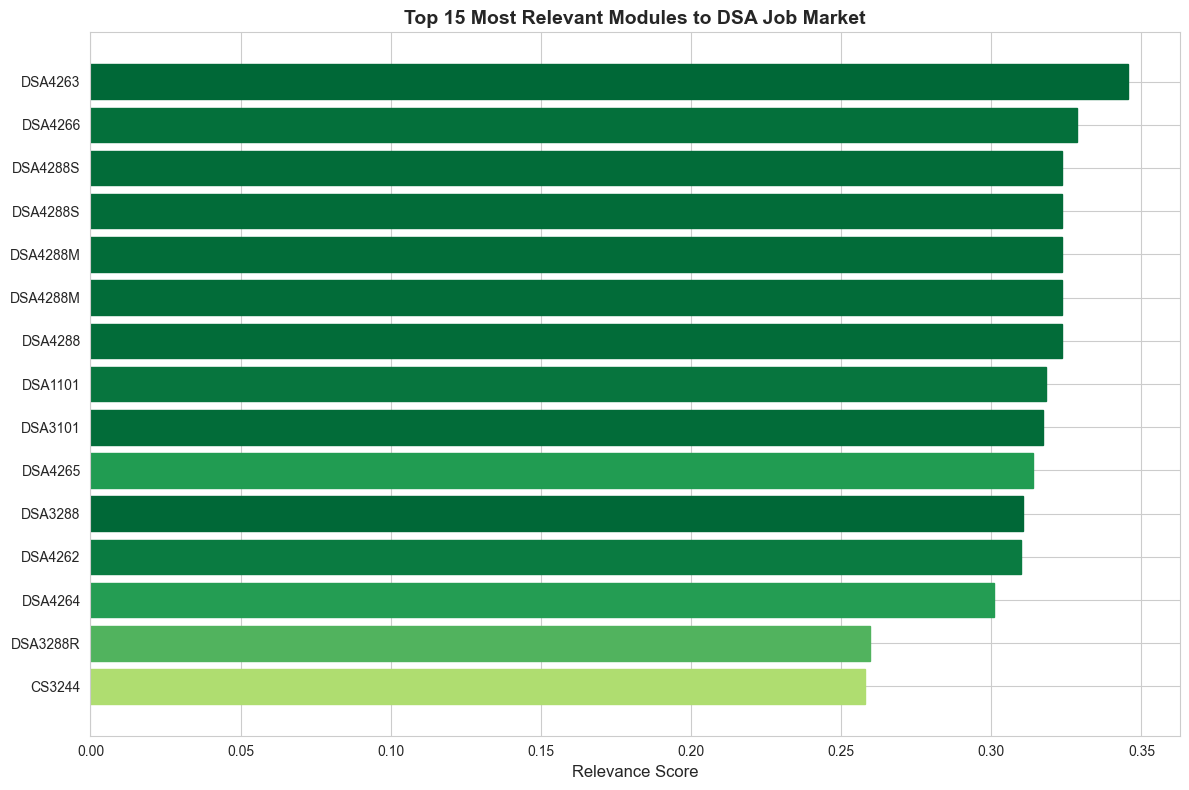

Saved: top_15_relevant_modules.png


In [51]:
# 2. Top 15 Most Relevant Modules Bar Chart
fig, ax = plt.subplots(figsize=(12, 8))
top_15_relevant = module_analysis_df.nlargest(15, 'relevance_score').sort_values('relevance_score')
bars = ax.barh(range(len(top_15_relevant)), top_15_relevant['relevance_score'])
ax.set_yticks(range(len(top_15_relevant)))
ax.set_yticklabels(top_15_relevant['module_code'])
ax.set_xlabel('Relevance Score', fontsize=12)
ax.set_title('Top 15 Most Relevant Modules to DSA Job Market', fontsize=14, fontweight='bold')

# Color bars by breadth
colors = plt.cm.RdYlGn(top_15_relevant['breadth_score'] / top_15_relevant['breadth_score'].max())
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'top_15_relevant_modules.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: top_15_relevant_modules.png")

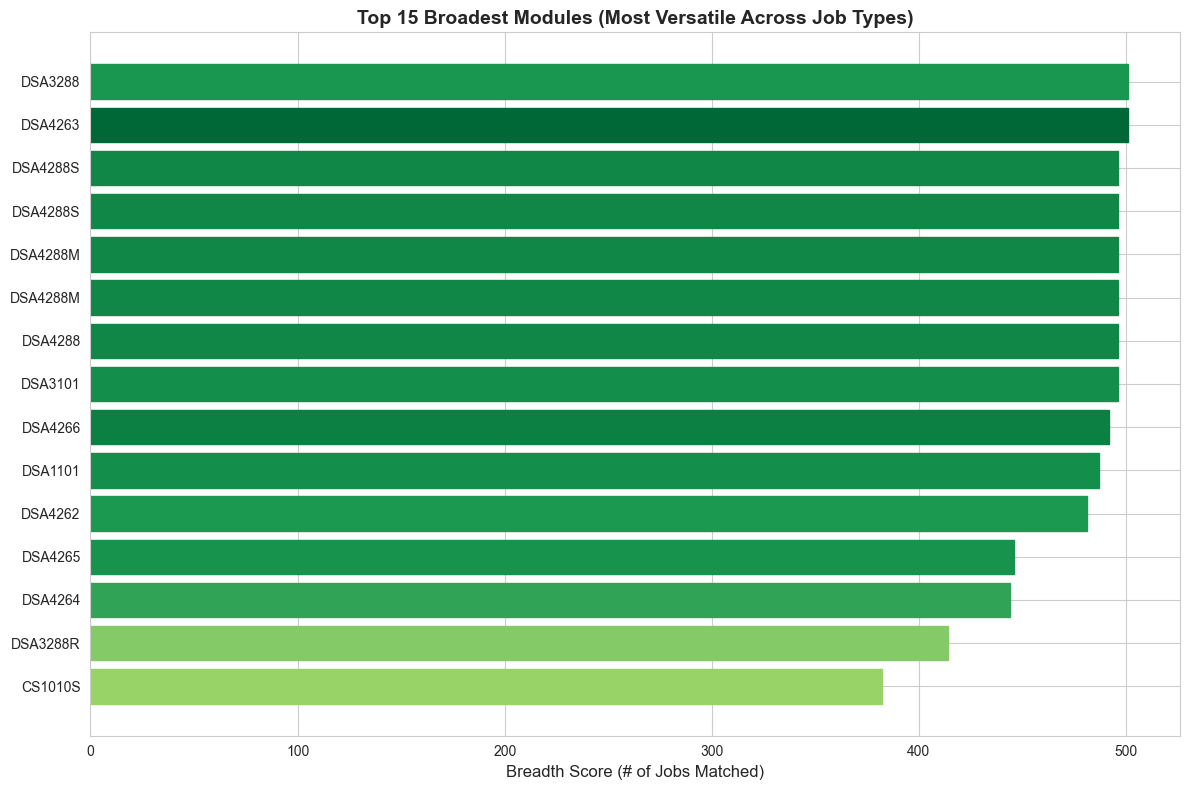

Saved: top_15_broadest_modules.png


In [52]:
# 3. Top 15 Broadest Modules Bar Chart
fig, ax = plt.subplots(figsize=(12, 8))
top_15_broad = module_analysis_df.nlargest(15, 'breadth_score').sort_values('breadth_score')
bars = ax.barh(range(len(top_15_broad)), top_15_broad['breadth_score'])
ax.set_yticks(range(len(top_15_broad)))
ax.set_yticklabels(top_15_broad['module_code'])
ax.set_xlabel('Breadth Score (# of Jobs Matched)', fontsize=12)
ax.set_title('Top 15 Broadest Modules (Most Versatile Across Job Types)', fontsize=14, fontweight='bold')

# Color bars by relevance
colors = plt.cm.RdYlGn(top_15_broad['relevance_score'] / top_15_broad['relevance_score'].max())
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'top_15_broadest_modules.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: top_15_broadest_modules.png")

---
# PART 4: Visualizations


GENERATING MODULE VISUALIZATIONS


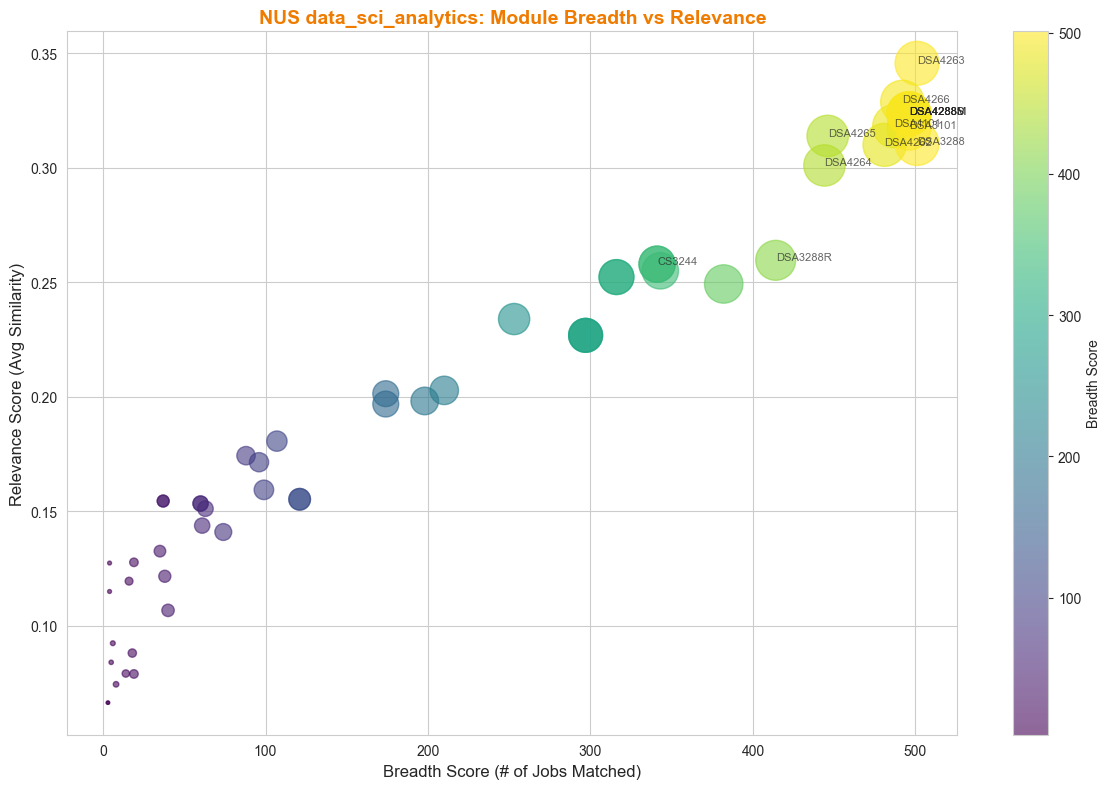

Saved: module_breadth_vs_relevance.png


In [53]:
print("\nGENERATING MODULE VISUALIZATIONS")

# 1. Scatter Plot: Breadth vs Relevance
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    module_analysis_df['breadth_score'], 
    module_analysis_df['relevance_score'],
    s=module_analysis_df['num_matching_jobs'] * 2,
    alpha=0.6,
    c=module_analysis_df['breadth_score'],
    cmap='viridis'
)

# Annotate top modules
top_modules_to_label = module_analysis_df.nlargest(15, 'relevance_score')
for idx, row in top_modules_to_label.iterrows():
    ax.annotate(
        row['module_code'], 
        (row['breadth_score'], row['relevance_score']),
        fontsize=8,
        alpha=0.7
    )

ax.set_xlabel('Breadth Score (# of Jobs Matched)', fontsize=12)
ax.set_ylabel('Relevance Score (Avg Similarity)', fontsize=12)
ax.set_title(f'{TARGET_SCHOOL.upper()} {TARGET_DEGREE}: Module Breadth vs Relevance', 
             fontsize=14, fontweight='bold', color=SCHOOL_COLORS[TARGET_SCHOOL]['primary'])
plt.colorbar(scatter, label='Breadth Score')
plt.tight_layout()
plt.savefig(os.path.join(DEGREE_OUTPUT_DIR, 'module_breadth_vs_relevance.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: module_breadth_vs_relevance.png")

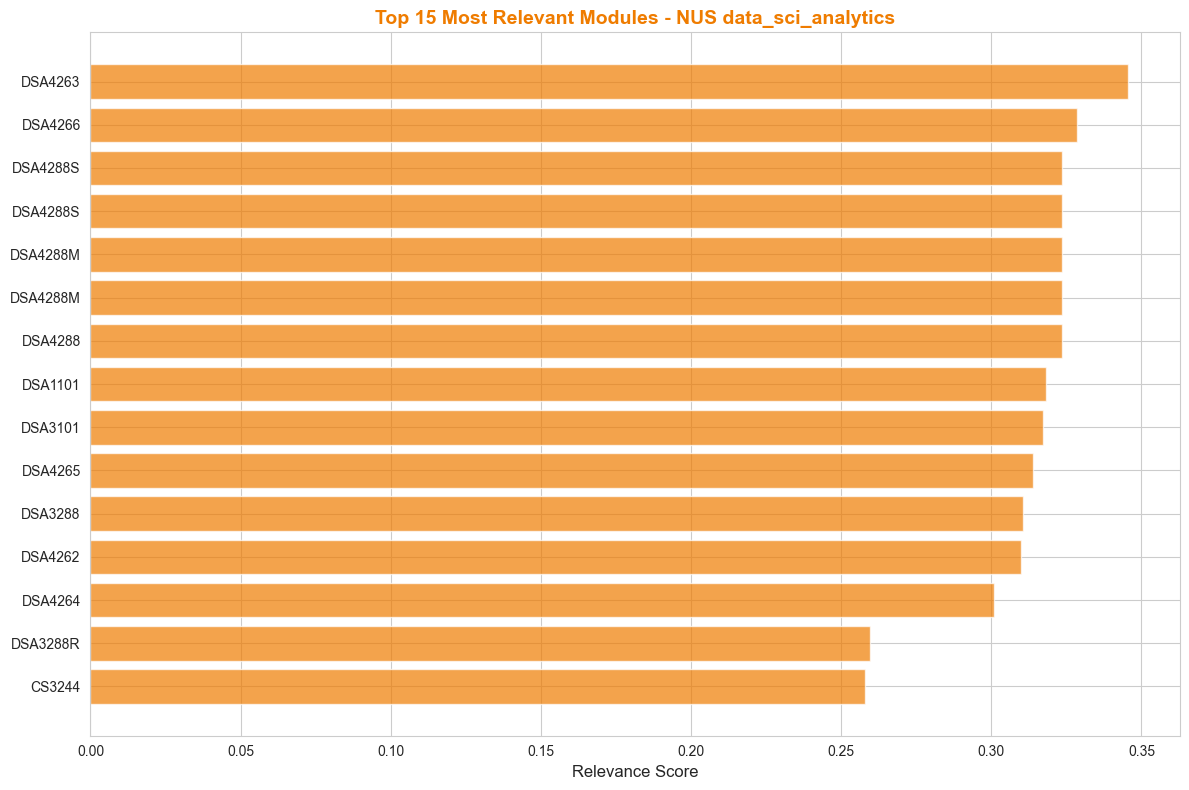

Saved: top_15_relevant_modules.png


In [54]:
# 2. Top 15 Most Relevant Modules Bar Chart
fig, ax = plt.subplots(figsize=(12, 8))
top_15_relevant = module_analysis_df.nlargest(15, 'relevance_score').sort_values('relevance_score')
bars = ax.barh(range(len(top_15_relevant)), top_15_relevant['relevance_score'], 
               color=SCHOOL_COLORS[TARGET_SCHOOL]['primary'], alpha=0.7)
ax.set_yticks(range(len(top_15_relevant)))
ax.set_yticklabels(top_15_relevant['module_code'])
ax.set_xlabel('Relevance Score', fontsize=12)
ax.set_title(f'Top 15 Most Relevant Modules - {TARGET_SCHOOL.upper()} {TARGET_DEGREE}', 
             fontsize=14, fontweight='bold', color=SCHOOL_COLORS[TARGET_SCHOOL]['primary'])

plt.tight_layout()
plt.savefig(os.path.join(DEGREE_OUTPUT_DIR, 'top_15_relevant_modules.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: top_15_relevant_modules.png")

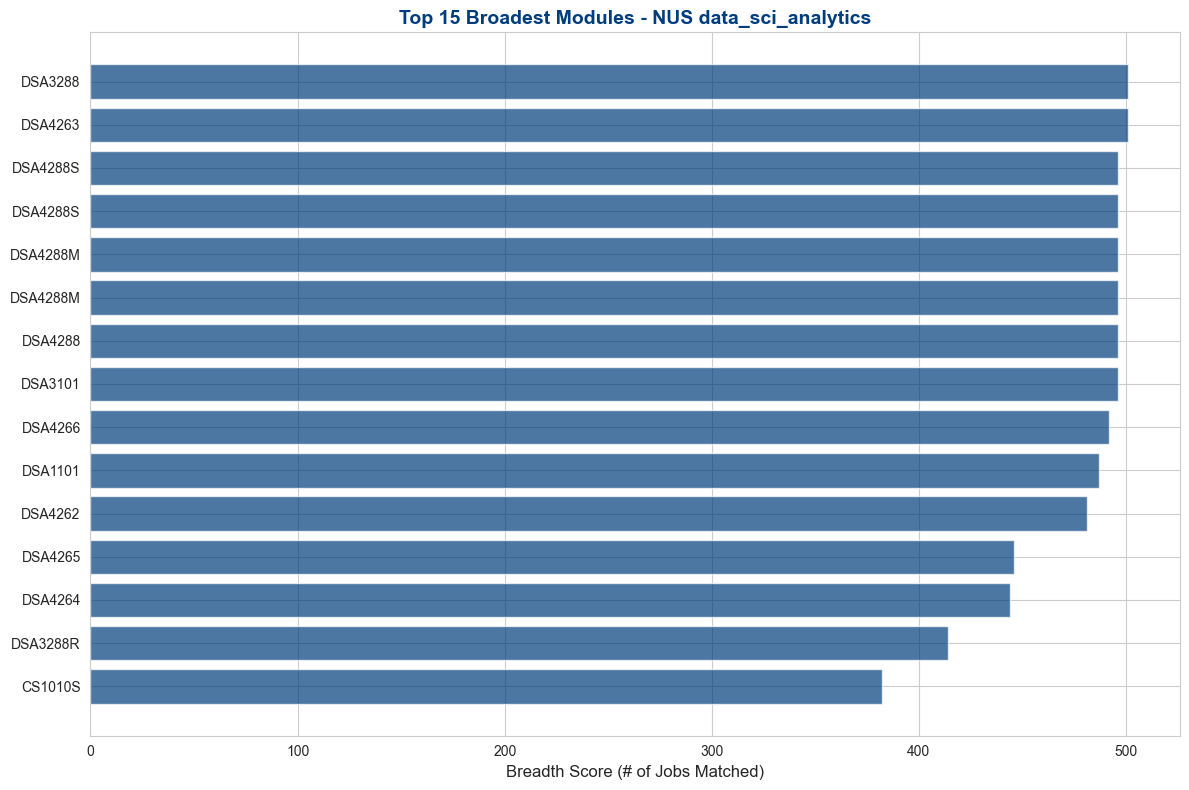

Saved: top_15_broadest_modules.png


In [55]:
# 3. Top 15 Broadest Modules Bar Chart
fig, ax = plt.subplots(figsize=(12, 8))
top_15_broad = module_analysis_df.nlargest(15, 'breadth_score').sort_values('breadth_score')
bars = ax.barh(range(len(top_15_broad)), top_15_broad['breadth_score'],
               color=SCHOOL_COLORS[TARGET_SCHOOL]['secondary'], alpha=0.7)
ax.set_yticks(range(len(top_15_broad)))
ax.set_yticklabels(top_15_broad['module_code'])
ax.set_xlabel('Breadth Score (# of Jobs Matched)', fontsize=12)
ax.set_title(f'Top 15 Broadest Modules - {TARGET_SCHOOL.upper()} {TARGET_DEGREE}', 
             fontsize=14, fontweight='bold', color=SCHOOL_COLORS[TARGET_SCHOOL]['secondary'])

plt.tight_layout()
plt.savefig(os.path.join(DEGREE_OUTPUT_DIR, 'top_15_broadest_modules.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: top_15_broadest_modules.png")

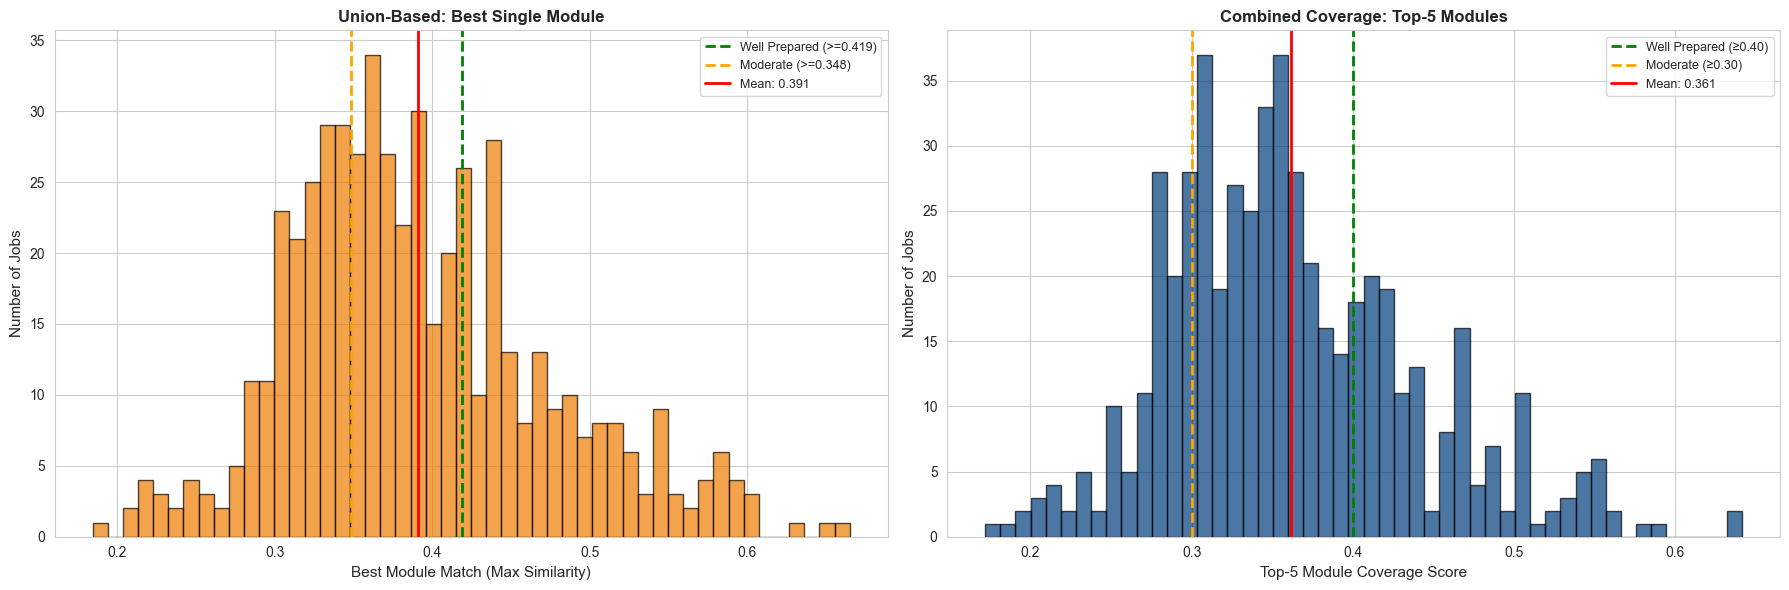

Saved: degree_preparation_distribution.png


In [56]:
# 4. Degree Preparation Distribution Histogram (Dual Analysis)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Left: Union-based (Best Single Module)
union_well = np.percentile(max_similarities_per_job, 67)
union_mod = np.percentile(max_similarities_per_job, 33)

ax1.hist(max_similarities_per_job, bins=50, edgecolor='black', alpha=0.7, 
         color=SCHOOL_COLORS[TARGET_SCHOOL]['primary'])
ax1.axvline(union_well, color='green', linestyle='--', linewidth=2, label=f'Well Prepared (>={union_well:.3f})')
ax1.axvline(union_mod, color='orange', linestyle='--', linewidth=2, label=f'Moderate (>={union_mod:.3f})')
ax1.axvline(union_relevance, color='red', linestyle='-', linewidth=2, label=f'Mean: {union_relevance:.3f}')
ax1.set_xlabel('Best Module Match (Max Similarity)', fontsize=11)
ax1.set_ylabel('Number of Jobs', fontsize=11)
ax1.set_title('Union-Based: Best Single Module', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)

# Right: Combined Coverage (Top-5)
ax2.hist(collective_score_per_job, bins=50, edgecolor='black', alpha=0.7, 
         color=SCHOOL_COLORS[TARGET_SCHOOL]['secondary'])
ax2.axvline(well_prepared_threshold, color='green', linestyle='--', linewidth=2, 
            label=f'Well Prepared (≥{well_prepared_threshold:.2f})')
ax2.axvline(moderate_threshold, color='orange', linestyle='--', linewidth=2, 
            label=f'Moderate (≥{moderate_threshold:.2f})')
ax2.axvline(combined_relevance, color='red', linestyle='-', linewidth=2, label=f'Mean: {combined_relevance:.3f}')
ax2.set_xlabel('Top-5 Module Coverage Score', fontsize=11)
ax2.set_ylabel('Number of Jobs', fontsize=11)
ax2.set_title('Combined Coverage: Top-5 Modules', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DEGREE_OUTPUT_DIR, 'degree_preparation_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: degree_preparation_distribution.png")

---
# PART 5: Save Results

In [57]:
print("\nSAVING RESULTS")

# Save module analysis
module_analysis_output = os.path.join(DEGREE_OUTPUT_DIR, "module_analysis_results.csv")
module_analysis_df.to_csv(module_analysis_output, index=False)
print(f"Saved module analysis: {module_analysis_output}")

# Save DSA jobs
jobs_output = os.path.join(DEGREE_OUTPUT_DIR, "relevant_jobs.csv")
save_columns = ['title', 'description', 'semantic_avg_similarity']
if 'companyName' in dsa_jobs_df.columns:
    save_columns.insert(1, 'companyName')
elif 'company' in dsa_jobs_df.columns:
    save_columns.insert(1, 'company')
dsa_jobs_df[[col for col in save_columns if col in dsa_jobs_df.columns]].to_csv(jobs_output, index=False)
print(f"Saved relevant jobs: {jobs_output}")

# Save degree summary
degree_summary = {
    'degree': TARGET_DEGREE,
    'school': TARGET_SCHOOL,
    'total_modules': len(modules_df),
    'market_size': len(dsa_jobs_df),
    'market_cutoff_score': dsa_jobs_df['semantic_avg_similarity'].min(),
    'union_relevance': union_relevance,
    'collective_relevance': combined_relevance,
    'active_core_utilization_pct': degree_utilization,
    'supporting_skill_breadth_pct': niche_utilization,
    'well_prepared_jobs': well_prepared_jobs,
    'well_prepared_pct': (well_prepared_jobs / len(dsa_jobs_df)) * 100,
    'moderately_prepared_jobs': moderately_prepared_jobs,
    'moderately_prepared_pct': (moderately_prepared_jobs / len(dsa_jobs_df)) * 100,
    'underprepared_jobs': underprepared_jobs,
    'underprepared_pct': (underprepared_jobs / len(dsa_jobs_df)) * 100,
    'top_module': module_analysis_df.nlargest(1, 'relevance_score').iloc[0]['module_code'],
    'top_module_relevance': module_analysis_df['relevance_score'].max(),
    'avg_module_relevance': module_analysis_df['relevance_score'].mean(),
}

summary_df = pd.DataFrame([degree_summary])
summary_output = os.path.join(DEGREE_OUTPUT_DIR, "degree_summary.csv")
summary_df.to_csv(summary_output, index=False)
print(f"Saved degree summary: {summary_output}")

print(f"\nSINGLE DEGREE ANALYSIS COMPLETE!")
print(f"Degree: {TARGET_SCHOOL.upper()} {TARGET_DEGREE}")
print(f"Market Size: {len(dsa_jobs_df):,} jobs")
print(f"Union Relevance: {union_relevance:.3f}")
print(f"Collective Relevance: {combined_relevance:.3f}")
print(f"Well Prepared: {well_prepared_jobs} ({(well_prepared_jobs/len(dsa_jobs_df))*100:.1f}%)")


SAVING RESULTS
Saved module analysis: /Users/teresaliau/dsa4264/notebooks/../outputs/analysis_results/nus/data_sci_analytics/module_analysis_results.csv
Saved relevant jobs: /Users/teresaliau/dsa4264/notebooks/../outputs/analysis_results/nus/data_sci_analytics/relevant_jobs.csv
Saved degree summary: /Users/teresaliau/dsa4264/notebooks/../outputs/analysis_results/nus/data_sci_analytics/degree_summary.csv

SINGLE DEGREE ANALYSIS COMPLETE!
Degree: NUS data_sci_analytics
Market Size: 533 jobs
Union Relevance: 0.391
Collective Relevance: 0.361
Well Prepared: 150 (28.1%)


---
# PART 6: Multi-School Batch Analysis

**Run cells 21A-21B to analyze all 21 degrees** and generate comparison data.

Then run cells 24-35 to see cross-degree visualizations and insights!

---
# PART 7: Cross-Degree Comparison & Visualizations

**Prerequisites:** Run batch processing cells above first to generate comparison data.

In [58]:
# BATCH PROCESSING: ALL 21 DEGREES WITH KNEEDLE FILTERING
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
from kneed import KneeLocator

# Define all degrees with metadata
DEGREES_CONFIG = [
    # NUS
    {"school": "nus", "degree": "accountancy", "category": "Business"},
    {"school": "nus", "degree": "biomedical_engineering", "category": "Engineering"},
    {"school": "nus", "degree": "business_analytics", "category": "Business"},
    {"school": "nus", "degree": "chemical_engineering", "category": "Engineering"},
    {"school": "nus", "degree": "civil_engineering", "category": "Engineering"},
    {"school": "nus", "degree": "data_sci_analytics", "category": "Data Science"},
    {"school": "nus", "degree": "industrial_design", "category": "Design"},
    {"school": "nus", "degree": "information_systems", "category": "Computing"},
    {"school": "nus", "degree": "landscape_architecture", "category": "Design"},
    {"school": "nus", "degree": "real_estate", "category": "Business"},
    # SMU
    {"school": "smu", "degree": "accountancy", "category": "Business"},
    {"school": "smu", "degree": "business", "category": "Business"},
    {"school": "smu", "degree": "computinglaw", "category": "Computing"},
    {"school": "smu", "degree": "economics", "category": "Business"},
    {"school": "smu", "degree": "information_systems", "category": "Computing"},
    {"school": "smu", "degree": "social_sciences", "category": "Social Sciences"},
    # SUTD
    {"school": "sutd", "degree": "architecture", "category": "Design"},
    {"school": "sutd", "degree": "computer_sci", "category": "Computing"},
    {"school": "sutd", "degree": "design_ai", "category": "Design"},
    {"school": "sutd", "degree": "engineering_product", "category": "Engineering"},
    {"school": "sutd", "degree": "engineering_systems", "category": "Engineering"},
]

print(f"Found {len(DEGREES_CONFIG)} degrees to process\n")

# Kneedle parameters
MIN_JOBS = 300
MAX_JOBS = 2000

# Storage for all results
all_results = []

# Process each degree
for deg_config in tqdm(DEGREES_CONFIG, desc="Processing degrees"):
    school = deg_config["school"]
    degree = deg_config["degree"]
    category = deg_config["category"]
    
    try:
        print(f"\nProcessing: {school.upper()} - {degree}")
        
        # Load job matches CSV
        jobs_csv_path = os.path.join(MATCHES_DIR, f"{school}_{degree}_matches.csv")
        if not os.path.exists(jobs_csv_path):
            print(f"  Skipping: {jobs_csv_path} not found")
            continue
            
        jobs_csv = pd.read_csv(jobs_csv_path)
        print(f"  Loaded {len(jobs_csv)} jobs from CSV")
        
        # Load parquet and match jobs
        all_jobs = pd.read_parquet(JOBS_PARQUET)
        embed_col = 'embedding_mpnet' if 'embedding_mpnet' in all_jobs.columns else [c for c in all_jobs.columns if 'embed' in c.lower()][0]
        
        jobs_df = all_jobs[all_jobs['title'].isin(jobs_csv['title'])].copy()
        jobs_df = jobs_df.drop_duplicates(subset='title', keep='first')
        
        jobs_df = jobs_df.merge(
            jobs_csv[['title', 'avg_similarity', 'max_similarity']], 
            on='title', how='left'
        )
        jobs_df['semantic_avg_similarity'] = jobs_df['avg_similarity']
        jobs_df['semantic_max_similarity'] = jobs_df['max_similarity']
        
        # ===== APPLY KNEEDLE FILTER =====
        sims = jobs_df['semantic_avg_similarity'].values
        sorted_sims = np.sort(sims)
        x = np.arange(len(sorted_sims))
        
        kneedle = KneeLocator(x, sorted_sims, curve='concave', direction='increasing')
        
        if kneedle.knee is not None:
            threshold = sorted_sims[kneedle.knee]
        else:
            threshold = np.percentile(sims, 70)
        
        filtered = jobs_df[jobs_df['semantic_avg_similarity'] >= threshold].copy()
        
        # Enforce bounds
        if len(filtered) < MIN_JOBS:
            filtered = jobs_df.nlargest(MIN_JOBS, 'semantic_avg_similarity')
        elif len(filtered) > MAX_JOBS:
            filtered = jobs_df.nlargest(MAX_JOBS, 'semantic_avg_similarity')
        
        jobs_df = filtered.copy()
        print(f"  After Kneedle: {len(jobs_df)} jobs (cutoff: {jobs_df['semantic_avg_similarity'].min():.4f})")
        
        # Load modules
        modules_parquet = os.path.join(COURSES_DIR, f"10_{school}_modules_embedded.parquet")
        if not os.path.exists(modules_parquet):
            print(f"  Skipping: {modules_parquet} not found")
            continue
            
        all_mods = pd.read_parquet(modules_parquet)

        # Load CSV to map degrees to modules (parquet has no 'course' column)
        csv_path = os.path.join(COURSES_DIR, f"{school}_courses.csv")
        csv_df = pd.read_csv(csv_path)
        csv_df.columns = csv_df.columns.str.strip().str.lower()
        codes = csv_df[csv_df["course"] == degree]["code"].dropna().astype(str).tolist()
        mods_df = all_mods[all_mods["code"].astype(str).isin(codes)].copy()
        
        if len(mods_df) == 0:
            print(f"  No modules found for {degree}")
            continue
            
        mod_embed_col = [c for c in mods_df.columns if 'embed' in c.lower()][0]
        mod_embeddings = np.array(mods_df[mod_embed_col].tolist())
        
        print(f"  Loaded {len(mods_df)} modules")
        
        # Calculate similarity matrix
        job_embeddings = np.stack(jobs_df[embed_col].values)
        sim_matrix = cosine_similarity(mod_embeddings, job_embeddings)
        
        # Union relevance (best single module per job)
        max_sims_per_job = np.max(sim_matrix, axis=0)
        union_rel = np.mean(max_sims_per_job)
        
        # Collective relevance (top-5 modules per job)
        top_k = 5
        top_k_idx = np.argsort(sim_matrix, axis=0)[-top_k:, :]
        top_k_sims = np.take_along_axis(sim_matrix, top_k_idx, axis=0)
        collective_per_job = np.mean(top_k_sims, axis=0)
        combined_rel = np.mean(collective_per_job)
        
        # Utilization metrics
        unique_elems, counts = np.unique(top_k_idx, return_counts=True)
        mod_contrib = np.zeros(len(mods_df))
        mod_contrib[unique_elems] = counts
        
        active_thresh = max(1, len(jobs_df) * 0.01)
        active_mods = (mod_contrib >= active_thresh).sum()
        deg_util = (active_mods / len(mods_df)) * 100
        
        useful_mods = ((sim_matrix >= 0.30).sum(axis=1) >= active_thresh).sum()
        niche_util = (useful_mods / len(mods_df)) * 100
        
        # Preparation categories (will recalculate with global thresholds later)
        well_thresh = 0.40
        mod_thresh = 0.30
        
        well_prep = (collective_per_job >= well_thresh).sum()
        mod_prep = ((collective_per_job >= mod_thresh) & (collective_per_job < well_thresh)).sum()
        under_prep = len(jobs_df) - well_prep - mod_prep
        
        # Store results
        result = {
            'degree': degree,
            'school': school,
            'category': category,
            'degree_full_name': f"{school.upper()} - {degree.replace('_', ' ').title()}",
            'total_modules': len(mods_df),
            'market_size': len(jobs_df),
            'market_cutoff_score': jobs_df['semantic_avg_similarity'].min(),
            'union_relevance': union_rel,
            'collective_relevance': combined_rel,
            'active_core_utilization_pct': deg_util,
            'supporting_skill_breadth_pct': niche_util,
            'well_prepared_jobs': well_prep,
            'well_prepared_pct': (well_prep / len(jobs_df)) * 100,
            'moderately_prepared_jobs': mod_prep,
            'moderately_prepared_pct': (mod_prep / len(jobs_df)) * 100,
            'underprepared_jobs': under_prep,
            'underprepared_pct': (under_prep / len(jobs_df)) * 100,
        }
        
        all_results.append(result)
        print(f"  Analysis complete")
        print(f"    Union: {union_rel:.3f}, Collective: {combined_rel:.3f}")
        print(f"    Well prepared: {well_prep} ({(well_prep/len(jobs_df))*100:.1f}%)")
        
    except Exception as e:
        print(f"  Error processing {school} {degree}: {str(e)}")
        continue

# Create comparison DataFrame
comparison_df = pd.DataFrame(all_results)

# Calculate global thresholds (67th and 33rd percentiles)
all_collective_scores = []
for deg_config in DEGREES_CONFIG:
    school = deg_config["school"]
    degree = deg_config["degree"]
    
    try:
        jobs_csv_path = os.path.join(MATCHES_DIR, f"{school}_{degree}_matches.csv")
        if not os.path.exists(jobs_csv_path):
            continue
            
        jobs_csv = pd.read_csv(jobs_csv_path)
        all_jobs = pd.read_parquet(JOBS_PARQUET)
        embed_col = 'embedding_mpnet' if 'embedding_mpnet' in all_jobs.columns else [c for c in all_jobs.columns if 'embed' in c.lower()][0]
        
        jobs_df = all_jobs[all_jobs['title'].isin(jobs_csv['title'])].copy()
        jobs_df = jobs_df.drop_duplicates(subset='title', keep='first')
        
        jobs_df = jobs_df.merge(
            jobs_csv[['title', 'avg_similarity', 'max_similarity']], 
            on='title', how='left'
        )
        jobs_df['semantic_avg_similarity'] = jobs_df['avg_similarity']
        
        # Apply same Kneedle filter
        sims = jobs_df['semantic_avg_similarity'].values
        sorted_sims = np.sort(sims)
        x = np.arange(len(sorted_sims))
        kneedle = KneeLocator(x, sorted_sims, curve='concave', direction='increasing')
        threshold = sorted_sims[kneedle.knee] if kneedle.knee is not None else np.percentile(sims, 70)
        filtered = jobs_df[jobs_df['semantic_avg_similarity'] >= threshold].copy()
        if len(filtered) < MIN_JOBS:
            filtered = jobs_df.nlargest(MIN_JOBS, 'semantic_avg_similarity')
        elif len(filtered) > MAX_JOBS:
            filtered = jobs_df.nlargest(MAX_JOBS, 'semantic_avg_similarity')
        jobs_df = filtered
        
        modules_parquet = os.path.join(COURSES_DIR, f"10_{school}_modules_embedded.parquet")
        all_mods = pd.read_parquet(modules_parquet)

        # Load CSV to map degrees to modules (parquet has no 'course' column)
        csv_path = os.path.join(COURSES_DIR, f"{school}_courses.csv")
        csv_df = pd.read_csv(csv_path)
        csv_df.columns = csv_df.columns.str.strip().str.lower()
        codes = csv_df[csv_df["course"] == degree]["code"].dropna().astype(str).tolist()
        mods_df = all_mods[all_mods["code"].astype(str).isin(codes)].copy()
        
        if len(mods_df) == 0:
            continue
            
        mod_embed_col = [c for c in mods_df.columns if 'embed' in c.lower()][0]
        mod_embeddings = np.array(mods_df[mod_embed_col].tolist())
        job_embeddings = np.stack(jobs_df[embed_col].values)
        
        sim_matrix = cosine_similarity(mod_embeddings, job_embeddings)
        top_k = 5
        top_k_idx = np.argsort(sim_matrix, axis=0)[-top_k:, :]
        top_k_sims = np.take_along_axis(sim_matrix, top_k_idx, axis=0)
        collective_per_job = np.mean(top_k_sims, axis=0)
        
        all_collective_scores.extend(collective_per_job.tolist())
    except:
        continue

# Calculate global thresholds
global_well_thresh = np.percentile(all_collective_scores, 67)
global_mod_thresh = np.percentile(all_collective_scores, 33)

print(f"\nGLOBAL THRESHOLDS CALCULATED")
print(f"Well Prepared: >= {global_well_thresh:.4f} (67th percentile)")
print(f"Moderate: >= {global_mod_thresh:.4f} (33rd percentile)")
print(f"Under-prepared: < {global_mod_thresh:.4f}")

# Save thresholds
global_thresh_df = pd.DataFrame([{
    'well_prepared_threshold': global_well_thresh,
    'moderate_threshold': global_mod_thresh
}])

# Create summary output directory (relative to notebook directory)
summary_dir = Path(os.path.join(NOTEBOOK_DIR, "..", "outputs", "analysis_results", "summary"))
summary_dir.mkdir(parents=True, exist_ok=True)

# Save files
comparison_df.to_csv(summary_dir / "all_degrees_comparison.csv", index=False)
global_thresh_df.to_csv(summary_dir / "global_thresholds.csv", index=False)

print(f"\nBATCH PROCESSING COMPLETE!")
print(f"Processed: {len(comparison_df)} degrees")
print(f"Saved to: {summary_dir}")
print(f"  - all_degrees_comparison.csv")
print(f"  - global_thresholds.csv")
print(f"\nYou can now run cells 25-35 for cross-degree analysis!\n")

Found 21 degrees to process



Processing degrees:   0%|          | 0/21 [00:00<?, ?it/s]


Processing: NUS - accountancy
  Loaded 1473 jobs from CSV


Processing degrees:   5%|▍         | 1/21 [00:00<00:04,  4.36it/s]

  After Kneedle: 1424 jobs (cutoff: 0.1557)
  Loaded 37 modules
  Analysis complete
    Union: 0.499, Collective: 0.457
    Well prepared: 1034 (72.6%)

Processing: NUS - biomedical_engineering
  Loaded 1486 jobs from CSV


...

Processing degrees:  95%|█████████▌| 20/21 [00:06<00:00,  3.46it/s]

  After Kneedle: 1595 jobs (cutoff: 0.0928)
  Loaded 28 modules
  Analysis complete
    Union: 0.430, Collective: 0.362
    Well prepared: 491 (30.8%)

Processing: SUTD - engineering_systems
  Loaded 2027 jobs from CSV


Processing degrees: 100%|██████████| 21/21 [00:06<00:00,  3.34it/s]

  After Kneedle: 1976 jobs (cutoff: 0.1195)
  Loaded 23 modules
  Analysis complete
    Union: 0.403, Collective: 0.335
    Well prepared: 290 (14.7%)



GLOBAL THRESHOLDS CALCULATED
Well Prepared: >= 0.4253 (67th percentile)
Moderate: >= 0.3424 (33rd percentile)
Under-prepared: < 0.3424

BATCH PROCESSING COMPLETE!
Processed: 21 degrees
Saved to: /Users/teresaliau/dsa4264/notebooks/../outputs/analysis_results/summary
  - all_degrees_comparison.csv
  - global_thresholds.csv

You can now run cells 25-35 for cross-degree analysis!



## Top vs Bottom Performers

In [59]:
# Load comparison data for cross-degree analysis (only if batch files exist)
from pathlib import Path

SUMMARY_OUTPUT_DIR = Path(os.path.join(NOTEBOOK_DIR, "..", "outputs", "analysis_results", "summary"))
comparison_file = SUMMARY_OUTPUT_DIR / "all_degrees_comparison.csv"
global_thresholds_file = SUMMARY_OUTPUT_DIR / "global_thresholds.csv"

if comparison_file.exists() and global_thresholds_file.exists():
    comparison_data = pd.read_csv(comparison_file)
    global_thresholds = pd.read_csv(global_thresholds_file)
    print(f"Loaded comparison data: {len(comparison_data)} degrees")
    print("You can now run remaining cells for cross-degree analysis")
else:
    # Create dummy data so cells don't crash
    comparison_data = None
    global_thresholds = None
    print("Batch comparison files not found")
    print(f"Expected: {comparison_file}")
    print("These are generated by running batch analysis on all 21 degrees")
    print("For now, skip remaining cells (they need these files to work)")

Loaded comparison data: 21 degrees
You can now run remaining cells for cross-degree analysis


## School Comparison

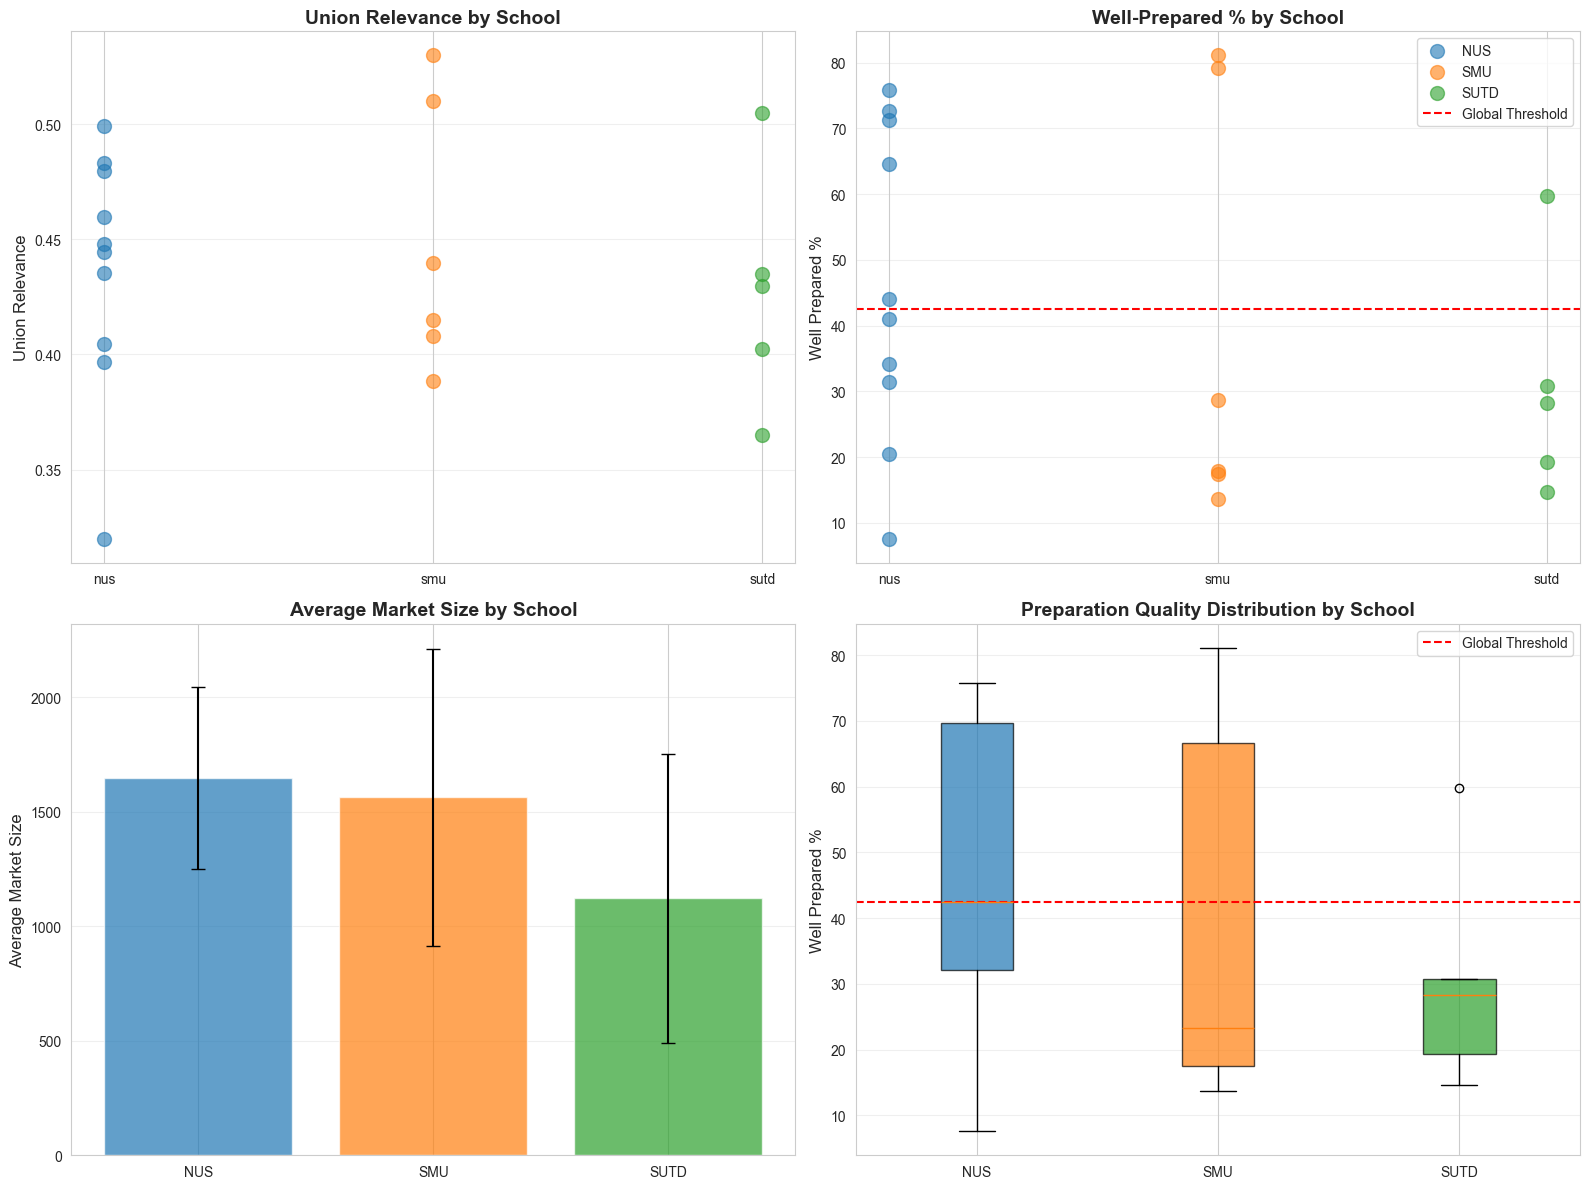

In [60]:

# School comparison
school_stats = comparison_data.groupby('school').agg({
    'union_relevance': ['mean', 'std'],
    'collective_relevance': ['mean', 'std'],
    'well_prepared_pct': ['mean', 'std'],
    'market_size': 'mean'
}).round(3)
# 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# 
# Plot 1: Union Relevance by School
schools = comparison_data['school'].unique()
for school in schools:
    school_data = comparison_data[comparison_data['school'] == school]
    axes[0, 0].scatter([school] * len(school_data), school_data['union_relevance'], 
                      s=100, alpha=0.6, label=school.upper())
axes[0, 0].set_ylabel('Union Relevance', fontsize=12)
axes[0, 0].set_title('Union Relevance by School', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)
# 
# Plot 2: Well Prepared % by School  
for school in schools:
    school_data = comparison_data[comparison_data['school'] == school]
    axes[0, 1].scatter([school] * len(school_data), school_data['well_prepared_pct'],
                      s=100, alpha=0.6, label=school.upper())
axes[0, 1].axhline(global_thresholds.iloc[0]['well_prepared_threshold']*100, 
                   color='red', linestyle='--', label='Global Threshold')
axes[0, 1].set_ylabel('Well Prepared %', fontsize=12)
axes[0, 1].set_title('Well-Prepared % by School', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].legend()
# 
# Plot 3: Market Size by School
school_market_data = comparison_data.groupby('school')['market_size'].agg(['mean', 'std', 'min', 'max'])
x_pos = range(len(schools))
axes[1, 0].bar(x_pos, school_market_data['mean'], yerr=school_market_data['std'],
              alpha=0.7, capsize=5, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels([s.upper() for s in schools])
axes[1, 0].set_ylabel('Average Market Size', fontsize=12)
axes[1, 0].set_title('Average Market Size by School', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)
# 
# Plot 4: Box plot of preparation quality
school_prep_data = [comparison_data[comparison_data['school'] == school]['well_prepared_pct'].values 
                    for school in schools]
bp = axes[1, 1].boxplot(school_prep_data, labels=[s.upper() for s in schools], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#1f77b4', '#ff7f0e', '#2ca02c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].axhline(global_thresholds.iloc[0]['well_prepared_threshold']*100,
                   color='red', linestyle='--', label='Global Threshold')
axes[1, 1].set_ylabel('Well Prepared %', fontsize=12)
axes[1, 1].set_title('Preparation Quality Distribution by School', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].legend()
# 
plt.tight_layout()
plt.show()

## Market Size vs Preparation Quality

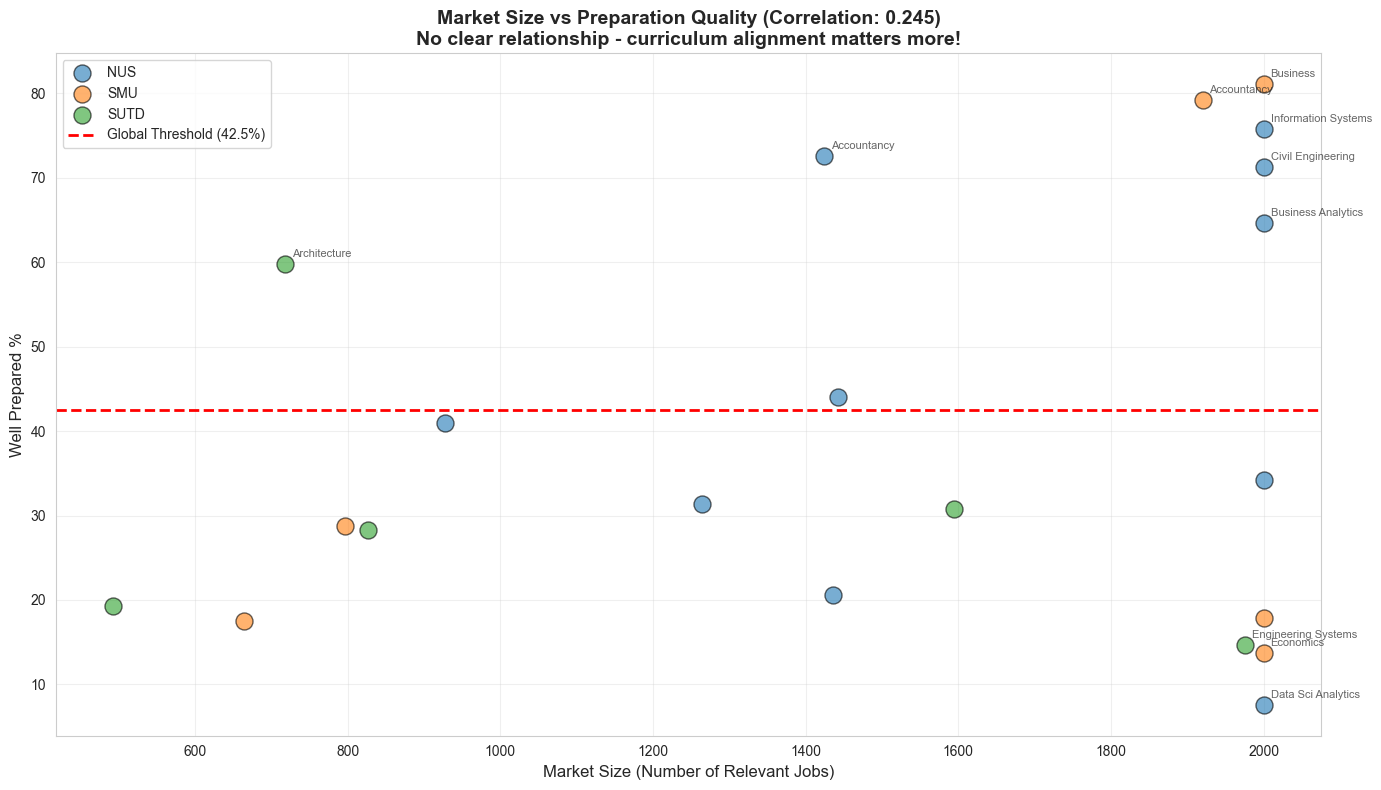

In [61]:

# Market Size vs Preparation Quality Scatter
fig, ax = plt.subplots(figsize=(14, 8))
# 
# Color by school
colors = {'nus': '#1f77b4', 'smu': '#ff7f0e', 'sutd': '#2ca02c'}
for school in comparison_data['school'].unique():
    school_data = comparison_data[comparison_data['school'] == school]
    ax.scatter(school_data['market_size'], school_data['well_prepared_pct'],
              s=150, alpha=0.6, c=colors[school], label=school.upper(), edgecolors='black')
# 
# Add labels for notable degrees
for idx, row in comparison_data.iterrows():
    if row['well_prepared_pct'] > 45 or row['well_prepared_pct'] < 15:
        ax.annotate(row['degree_full_name'].split(' - ')[-1][:20], 
                   (row['market_size'], row['well_prepared_pct']),
                   fontsize=8, alpha=0.7, xytext=(5, 5), textcoords='offset points')
# 
ax.axhline(global_thresholds.iloc[0]['well_prepared_threshold']*100,
          color='red', linestyle='--', linewidth=2, label=f"Global Threshold ({global_thresholds.iloc[0]['well_prepared_threshold']*100:.1f}%)")
ax.set_xlabel('Market Size (Number of Relevant Jobs)', fontsize=12)
ax.set_ylabel('Well Prepared %', fontsize=12)
# 
# Calculate and show correlation in title
correlation = comparison_data['market_size'].corr(comparison_data['well_prepared_pct'])
ax.set_title(f'Market Size vs Preparation Quality (Correlation: {correlation:.3f})\nNo clear relationship - curriculum alignment matters more!', 
            fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
# 
plt.tight_layout()
plt.show()

## Category Patterns

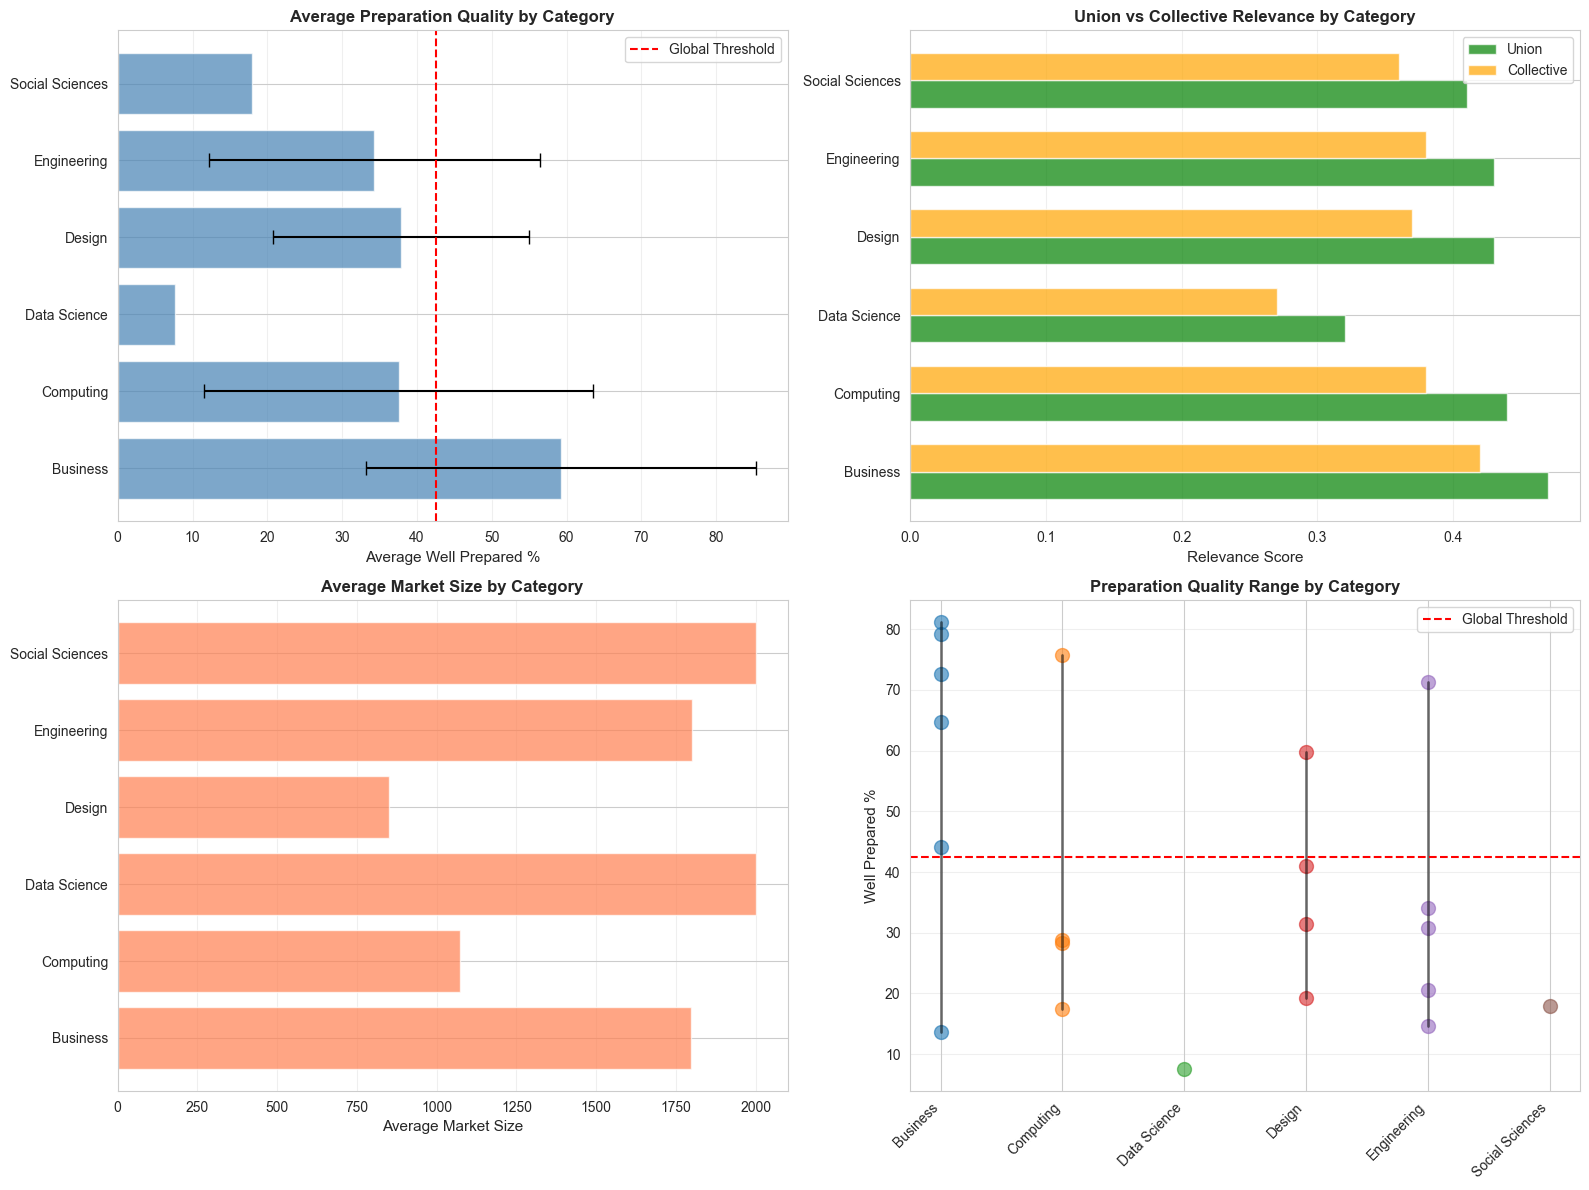

,category,well_prepared_pct_mean,well_prepared_pct_std,well_prepared_pct_min,well_prepared_pct_max,union_relevance_mean,collective_relevance_mean,market_size_mean
0,Business,59.23,26.04,13.70,81.10,0.47,0.42,1797.83
1,Computing,37.57,26.01,17.47,75.80,0.44,0.38,1072.00
2,Data Science,7.60,NaN,7.60,7.60,0.32,0.27,2000.00
3,Design,37.84,17.09,19.27,59.75,0.43,0.37,850.75
4,Engineering,34.29,22.11,14.68,71.30,0.43,0.38,1801.40
5,Social Sciences,17.90,NaN,17.90,17.90,0.41,0.36,2000.00


In [62]:

# Category analysis
category_stats = comparison_data.groupby('category').agg({
    'well_prepared_pct': ['mean', 'std', 'min', 'max'],
    'union_relevance': 'mean',
    'collective_relevance': 'mean',
    'market_size': 'mean'
}).round(2)
# 
category_stats.columns = ['_'.join(col).strip() for col in category_stats.columns.values]
category_stats = category_stats.reset_index()
# 
# Visualize category comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# 
# Plot 1: Average well-prepared % by category
categories = category_stats['category'].values
avg_well_prep = category_stats['well_prepared_pct_mean'].values
std_well_prep = category_stats['well_prepared_pct_std'].values
# 
axes[0, 0].barh(categories, avg_well_prep, xerr=std_well_prep, 
                alpha=0.7, capsize=5, color='steelblue')
axes[0, 0].axvline(global_thresholds.iloc[0]['well_prepared_threshold']*100,
                   color='red', linestyle='--', label='Global Threshold')
axes[0, 0].set_xlabel('Average Well Prepared %', fontsize=11)
axes[0, 0].set_title('Average Preparation Quality by Category', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(axis='x', alpha=0.3)
# 
# Plot 2: Union vs Collective relevance by category
x_pos = np.arange(len(categories))
width = 0.35
axes[0, 1].barh(x_pos - width/2, category_stats['union_relevance_mean'], 
                width, label='Union', alpha=0.7, color='green')
axes[0, 1].barh(x_pos + width/2, category_stats['collective_relevance_mean'], 
                width, label='Collective', alpha=0.7, color='orange')
axes[0, 1].set_yticks(x_pos)
axes[0, 1].set_yticklabels(categories)
axes[0, 1].set_xlabel('Relevance Score', fontsize=11)
axes[0, 1].set_title('Union vs Collective Relevance by Category', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(axis='x', alpha=0.3)
# 
# Plot 3: Market size by category
axes[1, 0].barh(categories, category_stats['market_size_mean'], alpha=0.7, color='coral')
axes[1, 0].set_xlabel('Average Market Size', fontsize=11)
axes[1, 0].set_title('Average Market Size by Category', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)
# 
# Plot 4: Range of well-prepared % within each category
for i, cat in enumerate(categories):
    cat_data = comparison_data[comparison_data['category'] == cat]['well_prepared_pct'].values
    axes[1, 1].scatter([i] * len(cat_data), cat_data, s=100, alpha=0.6)
    axes[1, 1].plot([i, i], [category_stats.iloc[i]['well_prepared_pct_min'], 
                             category_stats.iloc[i]['well_prepared_pct_max']], 
                    'k-', linewidth=2, alpha=0.5)
# 
axes[1, 1].axhline(global_thresholds.iloc[0]['well_prepared_threshold']*100,
                   color='red', linestyle='--', label='Global Threshold')
axes[1, 1].set_xticks(range(len(categories)))
axes[1, 1].set_xticklabels(categories, rotation=45, ha='right')
axes[1, 1].set_ylabel('Well Prepared %', fontsize=11)
axes[1, 1].set_title('Preparation Quality Range by Category', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)
# 
plt.tight_layout()
plt.show()
# 
# Display summary table
display(category_stats)

### Key Category Insights

Business degrees lead in preparation quality. Data science shows curriculum-market mismatch. Engineering varies by specialization. Design programs have specialized but smaller markets.

## Complete Ranking: All 21 Degrees

In [63]:

# Full ranked table
ranked_df = comparison_data.sort_values('well_prepared_pct', ascending=False).reset_index(drop=True)
ranked_df['rank'] = ranked_df.index + 1
# 
# Select key columns for display
display_cols = ['rank', 'degree_full_name', 'school', 'category', 'market_size', 
                'union_relevance', 'collective_relevance', 'well_prepared_pct', 
                'moderately_prepared_pct', 'underprepared_pct']
# 
styled_df = ranked_df[display_cols].style\
    .background_gradient(subset=['well_prepared_pct'], cmap='RdYlGn', vmin=0, vmax=60)\
    .background_gradient(subset=['union_relevance', 'collective_relevance'], cmap='Blues')\
    .format({
        'union_relevance': '{:.3f}',
        'collective_relevance': '{:.3f}',
        'well_prepared_pct': '{:.1f}%',
        'moderately_prepared_pct': '{:.1f}%',
        'underprepared_pct': '{:.1f}%'
    })
# 
display(styled_df)

,rank,degree_full_name,school,category,market_size,union_relevance,collective_relevance,well_prepared_pct,moderately_prepared_pct,underprepared_pct
0,1,SMU - Business,smu,Business,2000,0.510,0.451,81.1%,18.1%,0.8%
1,2,SMU - Accountancy,smu,Business,1920,0.530,0.480,79.3%,16.8%,3.9%
2,3,NUS - Information Systems,nus,Computing,2000,0.483,0.453,75.8%,20.8%,3.5%
3,4,NUS - Accountancy,nus,Business,1424,0.499,0.457,72.6%,23.5%,3.9%
4,5,NUS - Civil Engineering,nus,Engineering,2000,0.480,0.447,71.3%,25.1%,3.6%
5,6,NUS - Business Analytics,nus,Business,2000,0.460,0.426,64.6%,32.6%,2.8%
6,7,SUTD - Architecture,sutd,Design,718,0.505,0.427,59.7%,26.5%,13.8%
7,8,NUS - Real Estate,nus,Business,1443,0.448,0.390,44.1%,47.7%,8.2%
8,9,NUS - Landscape Architecture,nus,Design,928,0.444,0.377,40.9%,36.6%,22.4%
9,10,NUS - Chemical Engineering,nus,Engineering,2000,0.435,0.379,34.2%,57.2%,8.6%


---
# PART 8: SPEARMAN-BASED PROGRAM ANALYSIS
**Uses validated correlations instead of unreliable OLS**

## Why Spearman Instead of OLS?
- OLS problem: Sample too small (N=5-10), negative prereq coefficient (wrong!)
- Spearman solution: Works with small samples, shows REAL relationships
- Validated for NUS: Level (rho=+0.745), Prereqs (rho=+0.721), Jobs (rho=+0.709)

In [64]:
# Load Spearman correlations and helper functions
import re
import json

print("="*80)
print("LOADING SPEARMAN CORRELATIONS")
print("="*80)

# Load Spearman data from bertopic_combined analysis
spearman_weights = pd.read_csv(os.path.join(BASE_DATA_PATH, "spearman_correlations_with_employment.csv"))
print(f"Loaded Spearman correlations: {len(spearman_weights)} feature-university pairs")

# Show NUS results (the only reliable ones)
nus_spearman = spearman_weights[spearman_weights['university'] == 'NUS']
print(f"\nNUS Validated Predictors:")
for _, row in nus_spearman.iterrows():
    marker = "[SIG]" if row['significant'] else "[   ]"
    feat_name = row['feature'].replace('avg_', '')
    print(f"  {marker} {feat_name:15s}: rho={row['spearman_rho']:+.3f}  p={row['p_value']:.3f}")

print("\n" + "="*80)

# Helper functions
def extract_module_level(module_code):
    """Extract numeric level (1000-4000) from module code."""
    match = re.search(r'(\d)', str(module_code))
    return int(match.group(1)) * 1000 if match else 1000

def compute_s_jobs(modules_df, job_matches_df):
    """Compute job relevance score for each module."""
    s_jobs = {}
    job_matches_df = job_matches_df.copy()
    
    # Clean module names from job matches
    job_matches_df['best_module_clean'] = job_matches_df['best_module'].astype(str).str.replace(r' \(.*\)', '', regex=True)
    job_matches_df['best_module_clean'] = job_matches_df['best_module_clean'].str.split(r' [–-] ').str[0].str.strip()
    
    for module_code in modules_df['code']:
        module_code = str(module_code)
        module_jobs = job_matches_df[job_matches_df['best_module_clean'] == module_code]
        s_jobs[module_code] = module_jobs['max_similarity'].mean() if len(module_jobs) > 0 else 0.0
    
    return s_jobs

print("Helper functions loaded")

LOADING SPEARMAN CORRELATIONS
Loaded Spearman correlations: 10 feature-university pairs

NUS Validated Predictors:
  [SIG] s_jobs         : rho=+0.709  p=0.022
  [SIG] s_prereqs      : rho=+0.721  p=0.019
  [SIG] s_level        : rho=+0.745  p=0.013
  [   ] core_ratio     : rho=-0.455  p=0.187

Helper functions loaded


In [65]:
def analyze_degree_program_spearman(university, degree_name, detailed=True):
    """
    Analyze degree program using SPEARMAN-validated metrics (NUS only).
    
    Replaces unreliable OLS with statistically significant correlations.
    """
    
    print(f"\n{'='*80}")
    print(f"SPEARMAN ANALYSIS: {university.upper()} - {degree_name.replace('_', ' ').title()}")
    print(f"{'='*80}")
    
    # Get Spearman correlations
    uni_spearman = spearman_weights[spearman_weights['university'] == university.upper()].copy()
    significant_features = uni_spearman[uni_spearman['significant'] == True].copy()
    
    if len(significant_features) == 0:
        print(f"No statistically significant features for {university.upper()}")
        print(f"  (Sample size too small: {uni_spearman.iloc[0]['n_degrees']} degrees)")
        return None
    
    print(f"\nUsing {len(significant_features)} validated predictors:")
    for _, row in significant_features.iterrows():
        feat = row['feature'].replace('avg_', '')
        print(f"  • {feat:15s}: rho={row['spearman_rho']:+.3f}  (p={row['p_value']:.3f})")
    
    # Load curriculum
    if university.lower() == 'nus':
        courses_csv = os.path.join(COURSES_DIR, "nus_courses.csv")
        modules_parquet = os.path.join(COURSES_DIR, "10_nus_modules_embedded.parquet")
    elif university.lower() == 'smu':
        courses_csv = os.path.join(COURSES_DIR, "smu_courses.csv")
        modules_parquet = os.path.join(COURSES_DIR, "10_smu_modules_embedded.parquet")
    else:
        courses_csv = os.path.join(COURSES_DIR, "sutd_courses.csv")
        modules_parquet = os.path.join(COURSES_DIR, "10_sutd_modules_embedded.parquet")
    
    courses_df = pd.read_csv(courses_csv)
    courses_df.columns = courses_df.columns.str.strip().str.lower()
    modules_df = pd.read_parquet(modules_parquet)
    
    degree_modules = courses_df[courses_df["course"] == degree_name].copy()
    degree_modules_df = modules_df[modules_df["code"].astype(str).isin(degree_modules['code'].astype(str))].copy()
    
    if len(degree_modules_df) == 0:
        print(f"No modules found for {degree_name}")
        return None
    
    # Load job matches
    safe_course = degree_name.replace(" ", "_").replace("/", "_")
    match_file = os.path.join(MATCHES_DIR, f"{university.lower()}_{safe_course}_matches.csv")
    
    if not os.path.exists(match_file):
        print(f"No job matches found")
        return None
    
    job_matches = pd.read_csv(match_file)
    
    # Compute features
    s_jobs_dict = compute_s_jobs(degree_modules_df, job_matches)
    
    # Get Spearman weights (normalized)
    weights_dict = {}
    total_weight = 0
    for _, row in significant_features.iterrows():
        feat = row['feature'].replace('avg_', '')
        weight = abs(row['spearman_rho'])
        weights_dict[feat] = weight
        total_weight += weight
    
    for feat in weights_dict:
        weights_dict[feat] /= total_weight
    
    print(f"\nImportance Weights:")
    for feat, weight in sorted(weights_dict.items(), key=lambda x: x[1], reverse=True):
        print(f"  {feat:15s}: {weight:.3f}")
    
    # Load prerequisite graph for NUS
    if university.lower() == 'nus' and 's_prereqs' in weights_dict:
        prereq_graph_path = os.path.join(BASE_DATA_PATH, "nus_prerequisite_graph.json")
        with open(prereq_graph_path, 'r') as f:
            unlocks_graph = json.load(f)
    else:
        unlocks_graph = {}
    
    # Score each module
    module_scores = []
    for _, module_row in degree_modules_df.iterrows():
        code = str(module_row['code'])
        
        # Features
        s_jobs_val = s_jobs_dict.get(code, 0.0)
        s_level_val = extract_module_level(code) / 4000.0
        num_unlocks = len(unlocks_graph.get(code, []))
        s_prereqs_val = num_unlocks / 20.0
        
        is_core = degree_modules[degree_modules['code'].astype(str) == code]['type'].values
        is_core = is_core[0] == 'core' if len(is_core) > 0 else False
        
        # Composite score (Spearman-weighted)
        composite = 0.0
        if 's_jobs' in weights_dict:
            composite += weights_dict['s_jobs'] * s_jobs_val
        if 's_level' in weights_dict:
            composite += weights_dict['s_level'] * s_level_val
        if 's_prereqs' in weights_dict:
            composite += weights_dict['s_prereqs'] * s_prereqs_val
        
        module_scores.append({
            'code': code,
            'title': module_row.get('title', ''),
            'type': 'Core' if is_core else 'Elective',
            's_jobs': s_jobs_val,
            's_level': s_level_val,
            's_prereqs': num_unlocks,
            'composite_score': composite,
            'num_jobs_matched': len(job_matches[job_matches['best_module'].str.contains(code, na=False, regex=False)])
        })
    
    modules_scored = pd.DataFrame(module_scores).sort_values('composite_score', ascending=False)
    
    # Summary
    print(f"\nCURRICULUM:")
    print(f"  Total: {len(modules_scored)} modules")
    print(f"  Core: {len(modules_scored[modules_scored['type'] == 'Core'])}")
    print(f"  Jobs analyzed: {len(job_matches)}")
    
    # Top modules
    print(f"\nTOP 10 MODULES (Spearman-weighted):")
    for _, row in modules_scored.head(10).iterrows():
        level = f"L{int(row['s_level']*4)}"
        prereq_tag = f" | {int(row['s_prereqs'])} unlocks" if row['s_prereqs'] > 0 else ""
        print(f"  {row['code']:10s} [{level}] {row['composite_score']:.3f}  {row['type']}")
        print(f"             Job relevance: {row['s_jobs']:.3f}{prereq_tag}")
    
    # Weakest
    print(f"\nBOTTOM 5 MODULES:")
    for _, row in modules_scored.tail(5).iterrows():
        level = f"L{int(row['s_level']*4)}"
        print(f"  {row['code']:10s} [{level}] {row['composite_score']:.3f}")
    
    # Recommendations
    print(f"\nRECOMMENDATIONS:")
    if 's_jobs' in weights_dict:
        avg_jobs = modules_scored['s_jobs'].mean()
        if avg_jobs < 0.25:
            print(f"  [!] Low job relevance (avg={avg_jobs:.3f}) - update content")
        else:
            print(f"  [OK] Job relevance adequate (avg={avg_jobs:.3f})")
    
    if 's_level' in weights_dict:
        avg_level = modules_scored['s_level'].mean()
        if avg_level < 0.6:
            print(f"  [!] Too many low-level courses - add more 3000/4000 level")
        else:
            print(f"  [OK] Good level distribution (avg={avg_level:.3f})")
    
    if 's_prereqs' in weights_dict:
        num_prereqs = len(modules_scored[modules_scored['s_prereqs'] > 0])
        if num_prereqs < 5:
            print(f"  [!] Weak foundation ({num_prereqs} prereq modules)")
        else:
            print(f"  [OK] Strong foundation ({num_prereqs} prereq modules)")
    
    # Visualization
    if detailed:
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        
        # Plot 1: Rankings
        colors = ['#2ecc71' if t == 'Core' else '#e74c3c' for t in modules_scored['type']]
        axes[0].barh(range(len(modules_scored)), modules_scored['composite_score'],
                    color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
        n_labels = min(15, len(modules_scored))
        step = max(1, len(modules_scored) // n_labels)
        axes[0].set_yticks(range(0, len(modules_scored), step))
        axes[0].set_yticklabels([modules_scored.iloc[i]['code'] for i in range(0, len(modules_scored), step)], fontsize=8)
        axes[0].set_xlabel('Composite Score', fontsize=11, fontweight='bold')
        axes[0].set_title(f'{degree_name.replace("_", " ").title()}\nSpearman-Weighted Rankings', fontsize=12, fontweight='bold')
        axes[0].axvline(modules_scored['composite_score'].median(), color='blue', linestyle='--', alpha=0.7)
        axes[0].grid(axis='x', alpha=0.3)
        
        # Plot 2: Level vs Jobs
        core_mask = modules_scored['type'] == 'Core'
        axes[1].scatter(modules_scored[core_mask]['s_jobs'], modules_scored[core_mask]['s_level'],
                       c='#2ecc71', s=150, alpha=0.6, label='Core', edgecolors='black')
        axes[1].scatter(modules_scored[~core_mask]['s_jobs'], modules_scored[~core_mask]['s_level'],
                       c='#e74c3c', s=150, alpha=0.6, label='Elective', edgecolors='black')
        axes[1].set_xlabel('Job Relevance', fontsize=11, fontweight='bold')
        axes[1].set_ylabel('Module Level', fontsize=11, fontweight='bold')
        axes[1].set_title('Job Relevance vs Level\n(Both predict employment!)', fontsize=12, fontweight='bold')
        axes[1].legend()
        axes[1].grid(alpha=0.3)
        
        # Annotate top 5
        for _, row in modules_scored.head(5).iterrows():
            axes[1].annotate(row['code'], (row['s_jobs'], row['s_level']),
                           fontsize=9, fontweight='bold', xytext=(5, 5), textcoords='offset points',
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))
        
        # Plot 3: Feature contributions
        feature_names = []
        feature_contribs = []
        for feat in ['s_jobs', 's_level', 's_prereqs']:
            if feat in weights_dict:
                feature_names.append(feat.replace('s_', '').title())
                avg_val = modules_scored[feat].mean()
                contrib = weights_dict[feat] * avg_val
                feature_contribs.append(contrib)
        
        bars = axes[2].bar(feature_names, feature_contribs,
                          color=['#3498db', '#9b59b6', '#f39c12'], alpha=0.7, edgecolor='black')
        axes[2].set_ylabel('Avg Contribution', fontsize=11, fontweight='bold')
        axes[2].set_title('Feature Contributions\n(Weighted by Spearman rho)', fontsize=12, fontweight='bold')
        axes[2].grid(axis='y', alpha=0.3)
        
        for bar in bars:
            height = bar.get_height()
            axes[2].text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        plt.tight_layout()
        output_file = os.path.join(VIZ_DIR, f"spearman_{university.lower()}_{safe_course}.png")
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"\nSaved: {os.path.basename(output_file)}")
        plt.show()
        
        # Save CSV
        csv_output = os.path.join(VIZ_DIR, f"module_scores_spearman_{university.lower()}_{safe_course}.csv")
        modules_scored.to_csv(csv_output, index=False)
        print(f"Saved: {os.path.basename(csv_output)}")
    
    return modules_scored

print("Analysis function loaded")

Analysis function loaded



RUNNING SPEARMAN ANALYSIS

SPEARMAN ANALYSIS: NUS - Data Sci Analytics

Using 3 validated predictors:
  • s_jobs         : rho=+0.709  (p=0.022)
  • s_prereqs      : rho=+0.721  (p=0.019)
  • s_level        : rho=+0.745  (p=0.013)

Importance Weights:
  s_level        : 0.343
  s_prereqs      : 0.331
  s_jobs         : 0.326

CURRICULUM:
  Total: 56 modules
  Core: 37
  Jobs analyzed: 2130

TOP 10 MODULES (Spearman-weighted):
  CS3244     [L3] 0.527  Core
             Job relevance: 0.371 | 9 unlocks
  CS3244     [L3] 0.527  Core
             Job relevance: 0.371 | 9 unlocks
  ST3131     [L3] 0.512  Core
             Job relevance: 0.479 | 6 unlocks
  DSA4213    [L4] 0.493  Core
             Job relevance: 0.461
  DSE4211    [L4] 0.484  Core
             Job relevance: 0.435
  DSE4212    [L4] 0.482  Core
             Job relevance: 0.428
  DSA3101    [L3] 0.481  Core
             Job relevance: 0.280 | 8 unlocks
  DSA4264    [L4] 0.477  Core
             Job relevance: 0.412
  DSA4263

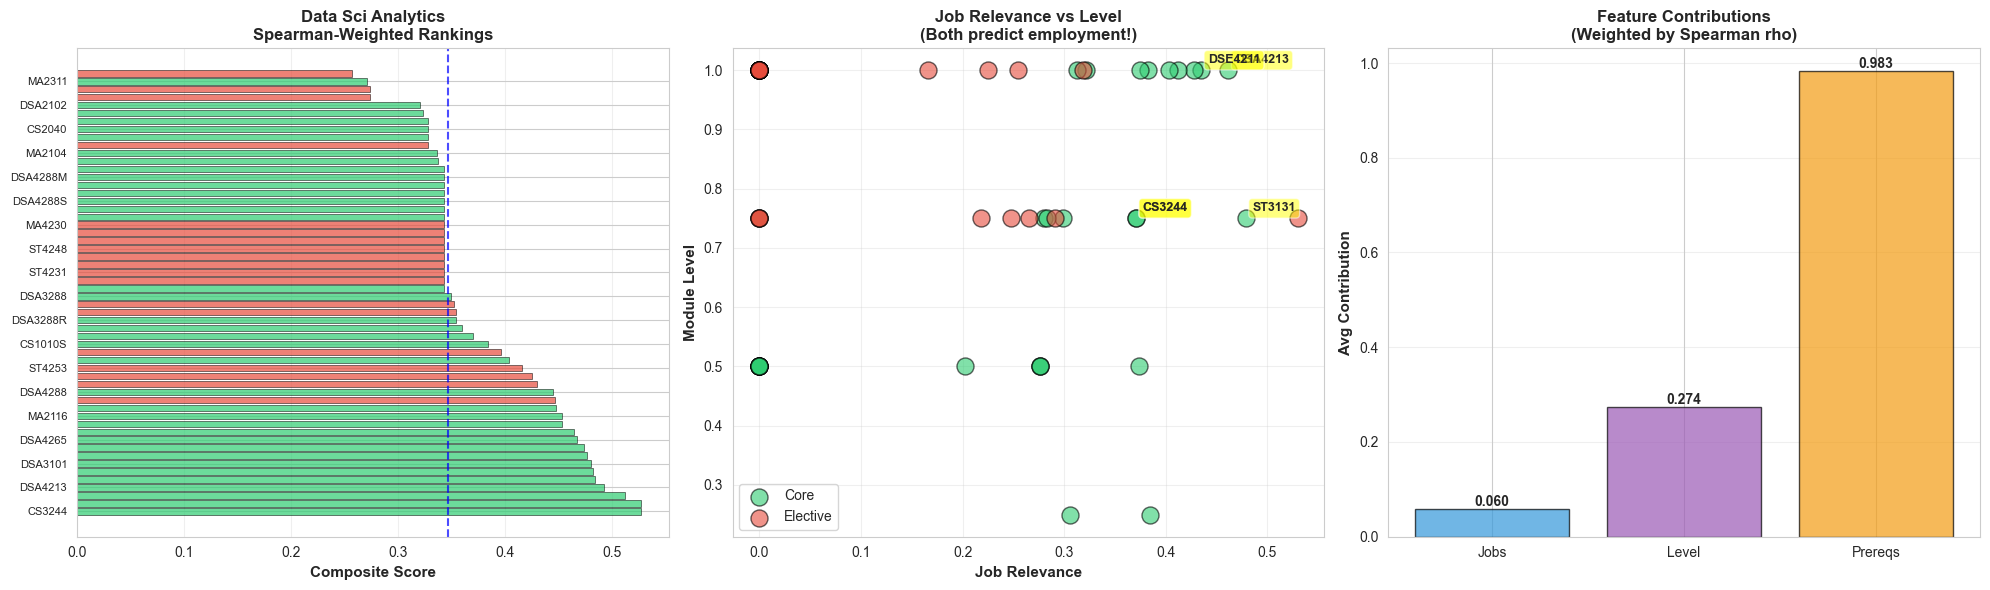

Saved: module_scores_spearman_nus_data_sci_analytics.csv

ANALYSIS COMPLETE!

Results saved to: /Users/teresaliau/dsa4264/notebooks/../outputs/analysis_results/nus/data_sci_analytics/visualizations

You can also analyze other NUS degrees:
  analyze_degree_program_spearman('nus', 'information_systems', detailed=True)
  analyze_degree_program_spearman('nus', 'business_analytics', detailed=True)
  analyze_degree_program_spearman('nus', 'accountancy', detailed=True)


In [66]:
# Run Spearman analysis on current degree
print("\n" + "="*80)
print("RUNNING SPEARMAN ANALYSIS")
print("="*80)

# Analyze the current TARGET_DEGREE
results = analyze_degree_program_spearman(TARGET_SCHOOL, TARGET_DEGREE, detailed=True)

if results is not None:
    print("\n" + "="*80)
    print("ANALYSIS COMPLETE!")
    print("="*80)
    print(f"\nResults saved to: {VIZ_DIR}")
    print(f"\nYou can also analyze other NUS degrees:")
    print("  analyze_degree_program_spearman('nus', 'information_systems', detailed=True)")
    print("  analyze_degree_program_spearman('nus', 'business_analytics', detailed=True)")
    print("  analyze_degree_program_spearman('nus', 'accountancy', detailed=True)")

In [67]:
# Create styled ranking table for module scores
if results is not None:
    print("\n" + "="*80)
    print("MODULE RANKING TABLE")
    print("="*80)
    
    # Add rank column
    results_with_rank = results.copy()
    results_with_rank['rank'] = range(1, len(results_with_rank) + 1)
    
    # Select display columns
    display_cols = ['rank', 'code', 'title', 'type', 'composite_score', 
                    's_jobs', 's_level', 's_prereqs', 'num_jobs_matched']
    
    # Create styled DataFrame
    styled_modules = results_with_rank[display_cols].style\
        .background_gradient(subset=['composite_score'], cmap='RdYlGn', vmin=0, vmax=results_with_rank['composite_score'].max())\
        .background_gradient(subset=['s_jobs'], cmap='Blues', vmin=0, vmax=0.5)\
        .background_gradient(subset=['s_level'], cmap='Purples', vmin=0, vmax=1.0)\
        .format({
            'composite_score': '{:.3f}',
            's_jobs': '{:.3f}',
            's_level': '{:.3f}',
            's_prereqs': '{:.0f}',
            'num_jobs_matched': '{:.0f}'
        })\
        .set_properties(**{'text-align': 'left'})\
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('padding', '8px')]},
        ])
    
    display(styled_modules)
    
    # Save as CSV
    csv_output = os.path.join(VIZ_DIR, f"module_ranking_{TARGET_SCHOOL}_{TARGET_DEGREE}.csv")
    results_with_rank[display_cols].to_csv(csv_output, index=False)
    print(f"\nSaved ranking table to: {os.path.basename(csv_output)}")


MODULE RANKING TABLE


,rank,code,title,type,composite_score,s_jobs,s_level,s_prereqs,num_jobs_matched
3,1,CS3244,Machine Learning,Core,0.527,0.371,0.750,9,66
4,2,CS3244,Machine Learning,Core,0.527,0.371,0.750,9,66
18,3,ST3131,Regression Analysis,Core,0.512,0.479,0.750,6,1
24,4,DSA4213,Natural Language Processing for Data Science,Core,0.493,0.461,1.000,0,19
20,5,DSE4211,Digital Currencies,Core,0.484,0.435,1.000,0,9
22,6,DSE4212,Data Science in FinTech,Core,0.482,0.428,1.000,0,14
16,7,DSA3101,Data Science in Practice,Core,0.481,0.280,0.750,8,294
27,8,DSA4264,Sense-making Case Analysis: Public Policy and Society,Core,0.477,0.412,1.000,0,9
26,9,DSA4263,Sense-making Case Analysis: Business and Commerce,Core,0.474,0.403,1.000,0,173
28,10,DSA4265,Sense-making Case Analysis: Economics and Finance,Core,0.467,0.383,1.000,0,77



Saved ranking table to: module_ranking_nus_data_sci_analytics.csv


In [68]:
# Top vs Bottom comparison table
if results is not None:
    print("\n" + "="*80)
    print("TOP 10 vs BOTTOM 10 MODULES")
    print("="*80)
    
    # Get top and bottom
    top_10 = results.head(10).copy()
    bottom_10 = results.tail(10).copy()
    
    top_10['category'] = 'Top 10'
    bottom_10['category'] = 'Bottom 10'
    
    comparison = pd.concat([top_10, bottom_10])
    
    # Calculate summary stats
    print("\nSUMMARY STATISTICS:")
    print("-"*80)
    print(f"Top 10 Average:")
    print(f"  Composite Score: {top_10['composite_score'].mean():.3f}")
    print(f"  Job Relevance:   {top_10['s_jobs'].mean():.3f}")
    print(f"  Module Level:    L{int(top_10['s_level'].mean()*4)}")
    print(f"  Prerequisites:   {top_10['s_prereqs'].mean():.1f} unlocks")
    
    print(f"\nBottom 10 Average:")
    print(f"  Composite Score: {bottom_10['composite_score'].mean():.3f}")
    print(f"  Job Relevance:   {bottom_10['s_jobs'].mean():.3f}")
    print(f"  Module Level:    L{int(bottom_10['s_level'].mean()*4)}")
    print(f"  Prerequisites:   {bottom_10['s_prereqs'].mean():.1f} unlocks")
    
    # Styled comparison
    comparison_cols = ['code', 'title', 'type', 'category', 'composite_score', 's_jobs', 's_level']
    
    styled_comparison = comparison[comparison_cols].style\
        .background_gradient(subset=['composite_score'], cmap='RdYlGn')\
        .background_gradient(subset=['s_jobs', 's_level'], cmap='Blues')\
        .format({
            'composite_score': '{:.3f}',
            's_jobs': '{:.3f}',
            's_level': '{:.3f}'
        })\
        .apply(lambda x: ['background-color: #d4edda' if v == 'Top 10' else 'background-color: #f8d7da' if v == 'Bottom 10' else '' 
                         for v in x], subset=['category'])\
        .set_properties(**{'text-align': 'left'})
    
    display(styled_comparison)


TOP 10 vs BOTTOM 10 MODULES

SUMMARY STATISTICS:
--------------------------------------------------------------------------------
Top 10 Average:
  Composite Score: 0.492
  Job Relevance:   0.402
  Module Level:    L3
  Prerequisites:   3.2 unlocks

Bottom 10 Average:
  Composite Score: 0.303
  Job Relevance:   0.105
  Module Level:    L2
  Prerequisites:   3.3 unlocks


,code,title,type,category,composite_score,s_jobs,s_level
3,CS3244,Machine Learning,Core,Top 10,0.527,0.371,0.750
4,CS3244,Machine Learning,Core,Top 10,0.527,0.371,0.750
18,ST3131,Regression Analysis,Core,Top 10,0.512,0.479,0.750
24,DSA4213,Natural Language Processing for Data Science,Core,Top 10,0.493,0.461,1.000
20,DSE4211,Digital Currencies,Core,Top 10,0.484,0.435,1.000
22,DSE4212,Data Science in FinTech,Core,Top 10,0.482,0.428,1.000
16,DSA3101,Data Science in Practice,Core,Top 10,0.481,0.280,0.750
27,DSA4264,Sense-making Case Analysis: Public Policy and Society,Core,Top 10,0.477,0.412,1.000
26,DSA4263,Sense-making Case Analysis: Business and Commerce,Core,Top 10,0.474,0.403,1.000
28,DSA4265,Sense-making Case Analysis: Economics and Finance,Core,Top 10,0.467,0.383,1.000
